# NB13a — Layer-by-Layer Constellation Analysis & Arditi Direction Validation

**Story:** How do task-conditioned behavioral representations form across the depth of a language model — and where does Arditi's refusal direction fit in this picture?

## Three Acts
- **Act 1 — Formation (Section 1–2):** Task constellations crystallize layer-by-layer. Early layers are input-dominated. Mid-layers show distinct task clusters. Late layers reveal the final common pathway — or show persistent divergence.
- **Act 2 — Crystallization (Section 3–4):** Within each task, the refusal vs. non-refusal decision commits at a task-specific layer. Staggering across tasks is evidence of task-conditioned processing, not a single shared circuit.
- **Act 3 — Arditi Validation (Section 5–6):** Is there a universal refusal direction across tasks? We measure when task-specific refusal directions converge — and whether that convergence fully explains Arditi's effectiveness, or leaves a systematic gap.

**Output:** 6 publication-quality figures (PDF, 300 DPI) + printed numeric summaries with interpretations.

**Compute:** ~5 min total | Embedding-only — no model inference required.

In [1]:
!pip install umap-learn -q

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import umap as umap_lib
from sklearn.metrics import silhouette_score
from itertools import combinations
import warnings
import os
import json

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size':        14,
    'axes.titlesize':   15,
    'axes.labelsize':   14,
    'legend.fontsize':  12,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'font.family':      'sans-serif',
    'lines.linewidth':  2.2,
})

TASK_COLORS = {
    'sentiment_analysis': '#E74C3C',
    'translate':          '#3498DB',
    'rephrase':           '#F39C12',
    'rag_qa':             '#27AE60',
    'cryptanalysis':      '#9B59B6',
}
BEH_MARKERS = {'target': 'o', 'over_refusal': 'X', 'refused_harmful': 's', 'other': '.'}
BEH_SIZES   = {'target': 22, 'over_refusal': 28, 'refused_harmful': 18, 'other': 7}
BEH_ALPHA   = {'target': 0.9, 'over_refusal': 0.9, 'refused_harmful': 0.7, 'other': 0.2}

def shade_phases(ax, n_layers=32):
    ax.axvspan(-0.5,  7.5,                  alpha=0.07, color='#95A5A6')
    ax.axvspan( 7.5, 19.5,                  alpha=0.07, color='#3498DB')
    ax.axvspan(19.5, float(n_layers) - 0.5, alpha=0.07, color='#E74C3C')
    for x, lbl, c in [(3.5,'Early\n(L00-07)','#7F8C8D'),
                      (13.5,'Mid\n(L08-19)','#2980B9'),
                      (25.5,'Late\n(L20-31)','#C0392B')]:
        ax.text(x, ax.get_ylim()[1]*0.96, lbl, ha='center', va='top',
                fontsize=10, color=c, fontweight='bold', alpha=0.75)

def fmt_layer(lname):
    return lname.replace('_input_norm', '').replace('layer_', 'L')

print('Setup complete')

Setup complete


In [2]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs('./embeddings',       exist_ok=True)
os.makedirs('./arditi_artefacts', exist_ok=True)
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings/.
!cp -a /content/drive/MyDrive/Colab\ Notebooks/SteeringFail/arditi_artefacts/* arditi_artefacts/

Mounted at /content/drive
cp: cannot open '/content/drive/MyDrive/embeddings/overalign_eval/llama/./overalign_eval_Meta-Llama-3.1-8B-Instruct_20250714_082134.gsheet' for reading: Operation not supported


In [3]:
def to_np(d):
    return {
        k: (v.float().numpy().astype(np.float32) if isinstance(v, torch.Tensor)
            else np.array([e.float().numpy().astype(np.float32) for e in v]))
        for k, v in d.items()
    }

embeddings_dir = './embeddings/'
csv_df         = pd.read_csv(os.path.join(embeddings_dir,
                    sorted([f for f in os.listdir(embeddings_dir) if f.endswith('.csv')])[-1]))
torch_data           = torch.load(csv_df['torch_path'].iloc[0])
embeddings_np        = to_np(torch_data['embeddings'])
texts                = torch_data['texts']
text_type_labels     = np.array(torch_data['text_type_labels'])
intended_task_labels = np.array(torch_data['intended_task_labels'])
response_labels      = csv_df['llm_evaluation'].values
refusal_labels       = csv_df['refusal_class'].values

ALL_TASKS   = sorted(np.unique(intended_task_labels).tolist())
N_SAMPLES   = len(texts)
LAYER_NAMES = [f'layer_{l}_input_norm' for l in range(32)
               if f'layer_{l}_input_norm' in embeddings_np]
N_LAYERS    = len(LAYER_NAMES)

print(f'{N_SAMPLES} samples | {N_LAYERS} layers | {len(ALL_TASKS)} tasks')
print(f'Tasks: {ALL_TASKS}')

270 samples | 31 layers | 5 tasks
Tasks: ['cryptanalysis', 'rag_qa', 'rephrase', 'sentiment_analysis', 'translate']


In [4]:
# ── Behavioral mask definitions (from NB5 SafeConstellations) ─
# Over-refusal is task-conditioned (by intended task), NOT by text_type_labels

# Target behavior: cautious or clean responses that still directly answer
TARGET_MASK = (
    ((response_labels == 'cautious') | (response_labels == 'not_harmful')) &
    (refusal_labels == 'direct_answer')
)

# Benign tasks: tasks that should not be refused
BENIGN_TASKS = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa']
benign_intent_mask = np.isin(intended_task_labels, BENIGN_TASKS)

# Over-refusal: model refuses a prompt whose task is benign in intent
refusing_mask     = (refusal_labels == 'direct_refusal') | (refusal_labels == 'indirect_refusal')
OVER_REFUSAL_MASK = refusing_mask & benign_intent_mask

# Refused-harmful: harmful text_type that was refused (Arditi class)
REFUSED_HARMFUL_MASK = (
    (text_type_labels == 'harmful_instruction') &
    refusing_mask
)

# Harmless-answered: benign text_type that was directly answered (Arditi class)
HARMLESS_ANSWERED_MASK = (
    (text_type_labels == 'benign_instruction') &
    (refusal_labels == 'direct_answer')
)

# Binary refusal label (all refused vs all answered, used for crystallization)
binary_refusal = np.where(refusing_mask, 'refused', 'answered')

# Behavioral label per sample (for UMAP coloring)
beh_labels = np.full(N_SAMPLES, 'other', dtype=object)
beh_labels[REFUSED_HARMFUL_MASK] = 'refused_harmful'
beh_labels[OVER_REFUSAL_MASK]    = 'over_refusal'
beh_labels[TARGET_MASK]          = 'target'

print('=== BEHAVIORAL LABEL DISTRIBUTION ===')
for lbl in ['target', 'over_refusal', 'refused_harmful', 'other']:
    print(f'  {lbl:<20}: {(beh_labels == lbl).sum():>4d}')
print()
print('=== TASK DISTRIBUTION ===')
for task in ALL_TASKS:
    n_tgt = (TARGET_MASK          & (intended_task_labels == task)).sum()
    n_or  = (OVER_REFUSAL_MASK    & (intended_task_labels == task)).sum()
    n_rh  = (REFUSED_HARMFUL_MASK & (intended_task_labels == task)).sum()
    n_tot = (intended_task_labels == task).sum()
    print(f'  {task:<22}: total={n_tot:>3d}  target={n_tgt:>3d}  '
          f'over_refusal={n_or:>3d}  refused_harmful={n_rh:>3d}')
print()
print('NOTE: OVER_REFUSAL_MASK uses intended_task_labels (task identity),')
print('not text_type_labels (input type) — matching NB5 SafeConstellations definition.')


=== BEHAVIORAL LABEL DISTRIBUTION ===
  target              :  169
  over_refusal        :   48
  refused_harmful     :    8
  other               :   45

=== TASK DISTRIBUTION ===
  cryptanalysis         : total= 60  target= 55  over_refusal=  0  refused_harmful=  0
  rag_qa                : total= 30  target= 30  over_refusal=  0  refused_harmful=  0
  rephrase              : total= 65  target= 29  over_refusal=  0  refused_harmful=  8
  sentiment_analysis    : total= 55  target= 32  over_refusal= 20  refused_harmful=  7
  translate             : total= 60  target= 23  over_refusal= 28  refused_harmful= 10

NOTE: OVER_REFUSAL_MASK uses intended_task_labels (task identity),
not text_type_labels (input type) — matching NB5 SafeConstellations definition.


In [5]:
# ============================================================
# PRE-COMPUTATION — run once, everything cached in dicts
# Runtime: ~4-7 min (dominated by UMAP x32 layers)
# ============================================================

print('Pre-computing all metrics across 32 layers...')
print('Progress shown per layer. Estimated time: 4-7 min\n')

# ── 1. UMAP + inter-task silhouette per layer ──────────────────
umap_2d             = {}   # lname -> (N,2)
task_sil_per_layer  = {}   # lname -> float  (inter-task silhouette)

for i, lname in enumerate(LAYER_NAMES):
    emb    = embeddings_np[lname]
    reducer = umap_lib.UMAP(n_components=2, n_neighbors=15,
                             min_dist=0.1, random_state=42)
    umap_2d[lname] = reducer.fit_transform(emb)
    try:
        sil = silhouette_score(emb, intended_task_labels, metric='euclidean')
    except Exception:
        sil = np.nan
    task_sil_per_layer[lname] = sil
    print(f'  L{i:02d}: UMAP done | inter-task silhouette = {sil:.3f}')

print()

# ── 2. Layer profile metrics ───────────────────────────────────
inter_centroid_dist = {}
intra_task_spread   = {}
separation_ratio    = {}
centroid_matrices   = {}   # lname -> (N_TASKS x N_TASKS)
task_centroids_all  = {}   # lname -> {task: vector}

for lname in LAYER_NAMES:
    emb   = embeddings_np[lname]
    cents = {t: emb[intended_task_labels == t].mean(0) for t in ALL_TASKS}
    task_centroids_all[lname] = cents

    pairwise = []
    dmat     = np.zeros((len(ALL_TASKS), len(ALL_TASKS)))
    for ii, ti in enumerate(ALL_TASKS):
        for jj, tj in enumerate(ALL_TASKS):
            d = float(np.linalg.norm(cents[ti] - cents[tj]))
            dmat[ii, jj] = d
            if ii < jj:
                pairwise.append(d)
    inter_centroid_dist[lname] = float(np.mean(pairwise))
    centroid_matrices[lname]   = dmat

    spreads = []
    for t in ALL_TASKS:
        t_emb = emb[intended_task_labels == t]
        spreads.extend(np.linalg.norm(t_emb - cents[t], axis=1).tolist())
    intra_task_spread[lname]  = float(np.mean(spreads))
    separation_ratio[lname]   = inter_centroid_dist[lname] / (intra_task_spread[lname] + 1e-8)

print('Layer profile metrics done.')

# ── 3. Within-task refusal crystallization silhouette ─────────
cryst_sil = {}   # (task, lname) -> float

for lname in LAYER_NAMES:
    emb = embeddings_np[lname]
    for task in ALL_TASKS:
        mask  = intended_task_labels == task
        t_emb = emb[mask]
        t_bin = binary_refusal[mask]
        if (t_bin == 'refused').sum() < 2 or (t_bin == 'answered').sum() < 2:
            cryst_sil[(task, lname)] = np.nan
            continue
        try:
            cryst_sil[(task, lname)] = float(silhouette_score(t_emb, t_bin, metric='euclidean'))
        except Exception:
            cryst_sil[(task, lname)] = np.nan

print('Crystallization silhouettes done.')

# ── 4. Per-task refusal directions (all layers) ────────────────
task_dirs       = {}   # (task, lname) -> unit vector
VALID_DIR_TASKS = []
for task in ALL_TASKS:
    n_r = (REFUSED_HARMFUL_MASK  & (intended_task_labels == task)).sum()
    n_h = (HARMLESS_ANSWERED_MASK & (intended_task_labels == task)).sum()
    if n_r >= 3 and n_h >= 3:
        VALID_DIR_TASKS.append(task)
        tr = REFUSED_HARMFUL_MASK  & (intended_task_labels == task)
        th = HARMLESS_ANSWERED_MASK & (intended_task_labels == task)
        for lname in LAYER_NAMES:
            emb = embeddings_np[lname]
            d   = emb[tr].mean(0) - emb[th].mean(0)
            task_dirs[(task, lname)] = d / (np.linalg.norm(d) + 1e-8)

print(f'Per-task refusal directions done. Valid tasks: {VALID_DIR_TASKS}')

# ── 5. Load Arditi per-layer candidate directions ──────────────
arditi_dirs = {}
try:
    raw = torch.load('arditi_artefacts/candidate_directions.pt')
    for k, v in raw.items():
        d = v.numpy().astype(np.float32) if isinstance(v, torch.Tensor) else np.array(v, dtype=np.float32)
        arditi_dirs[k] = d / (np.linalg.norm(d) + 1e-8)
    print(f'Arditi per-layer directions loaded: {len(arditi_dirs)} layers')
except Exception as e:
    print(f'Warning: Arditi directions not loaded: {e}')

# ── 6. Cross-task direction similarity + Arditi alignment ──────
dir_pairs    = list(combinations(VALID_DIR_TASKS, 2))
pair_sims    = {p: [] for p in dir_pairs}
arditi_align = {t: [] for t in VALID_DIR_TASKS}
mean_cross_sim = []

if len(VALID_DIR_TASKS) >= 2:
    for lname in LAYER_NAMES:
        for t1, t2 in dir_pairs:
            if (t1, lname) in task_dirs and (t2, lname) in task_dirs:
                pair_sims[(t1, t2)].append(float(np.dot(task_dirs[(t1, lname)], task_dirs[(t2, lname)])))
            else:
                pair_sims[(t1, t2)].append(np.nan)
        for t in VALID_DIR_TASKS:
            if (t, lname) in task_dirs and lname in arditi_dirs:
                arditi_align[t].append(float(np.dot(task_dirs[(t, lname)], arditi_dirs[lname])))
            else:
                arditi_align[t].append(np.nan)
    mean_cross_sim = [
        float(np.nanmean([pair_sims[p][i] for p in dir_pairs]))
        for i in range(N_LAYERS)
    ]
    print('Cross-task direction similarities done.')
else:
    mean_cross_sim = [np.nan] * N_LAYERS
    print('Warning: fewer than 2 valid direction tasks.')

print('\nAll pre-computations complete. Ready to generate figures.')

Pre-computing all metrics across 32 layers...
Progress shown per layer. Estimated time: 4-7 min

  L00: UMAP done | inter-task silhouette = 0.000
  L01: UMAP done | inter-task silhouette = 0.270
  L02: UMAP done | inter-task silhouette = 0.269
  L03: UMAP done | inter-task silhouette = 0.300
  L04: UMAP done | inter-task silhouette = 0.307
  L05: UMAP done | inter-task silhouette = 0.279
  L06: UMAP done | inter-task silhouette = 0.304
  L07: UMAP done | inter-task silhouette = 0.319
  L08: UMAP done | inter-task silhouette = 0.332
  L09: UMAP done | inter-task silhouette = 0.327
  L10: UMAP done | inter-task silhouette = 0.337
  L11: UMAP done | inter-task silhouette = 0.345
  L12: UMAP done | inter-task silhouette = 0.357
  L13: UMAP done | inter-task silhouette = 0.345
  L14: UMAP done | inter-task silhouette = 0.344
  L15: UMAP done | inter-task silhouette = 0.342
  L16: UMAP done | inter-task silhouette = 0.343
  L17: UMAP done | inter-task silhouette = 0.340
  L18: UMAP done | in

---
## Section 1 — The 32-Layer Behavioral Galaxy Map  [NB7-aligned]

**Framing change from original NB13a:** In NB7 we established that task constellations dominate the embedding geometry, and behavioral separation (target vs. over-refusal) is a *within-cluster* signal. This section now puts that to the test across all 32 layers.

**Figure 1 — Behavioral Galaxy Grid:** Primary color = behavioral class (green = target/answered; red = over-refusal/benign refused; orange = refused-harmful; grey = other). Task identity shown as faint background clouds.

**Figure 1b — Dual Galaxy Map:** At the peak-constellation layer, the SAME UMAP is shown twice: LEFT = task identity, RIGHT = behavioral class. This directly answers: do the red X marks (over-refusal) form a global "refusal cluster" independent of task, or do they sit *inside* task-coloured clouds?

**Figure 1c — Per-Task Behavioral Separation:** Centroid distance (target vs. over-refusal) and within-task silhouette per task, computed in high-dim space across all 32 layers — with the mean inter-task distance plotted as a scale reference. This answers whether the behavioral gap is large or negligible relative to the task gap.

**Silhouette score in panel titles:** Still the inter-task silhouette — tracks task constellation strength, not behavioral separation.

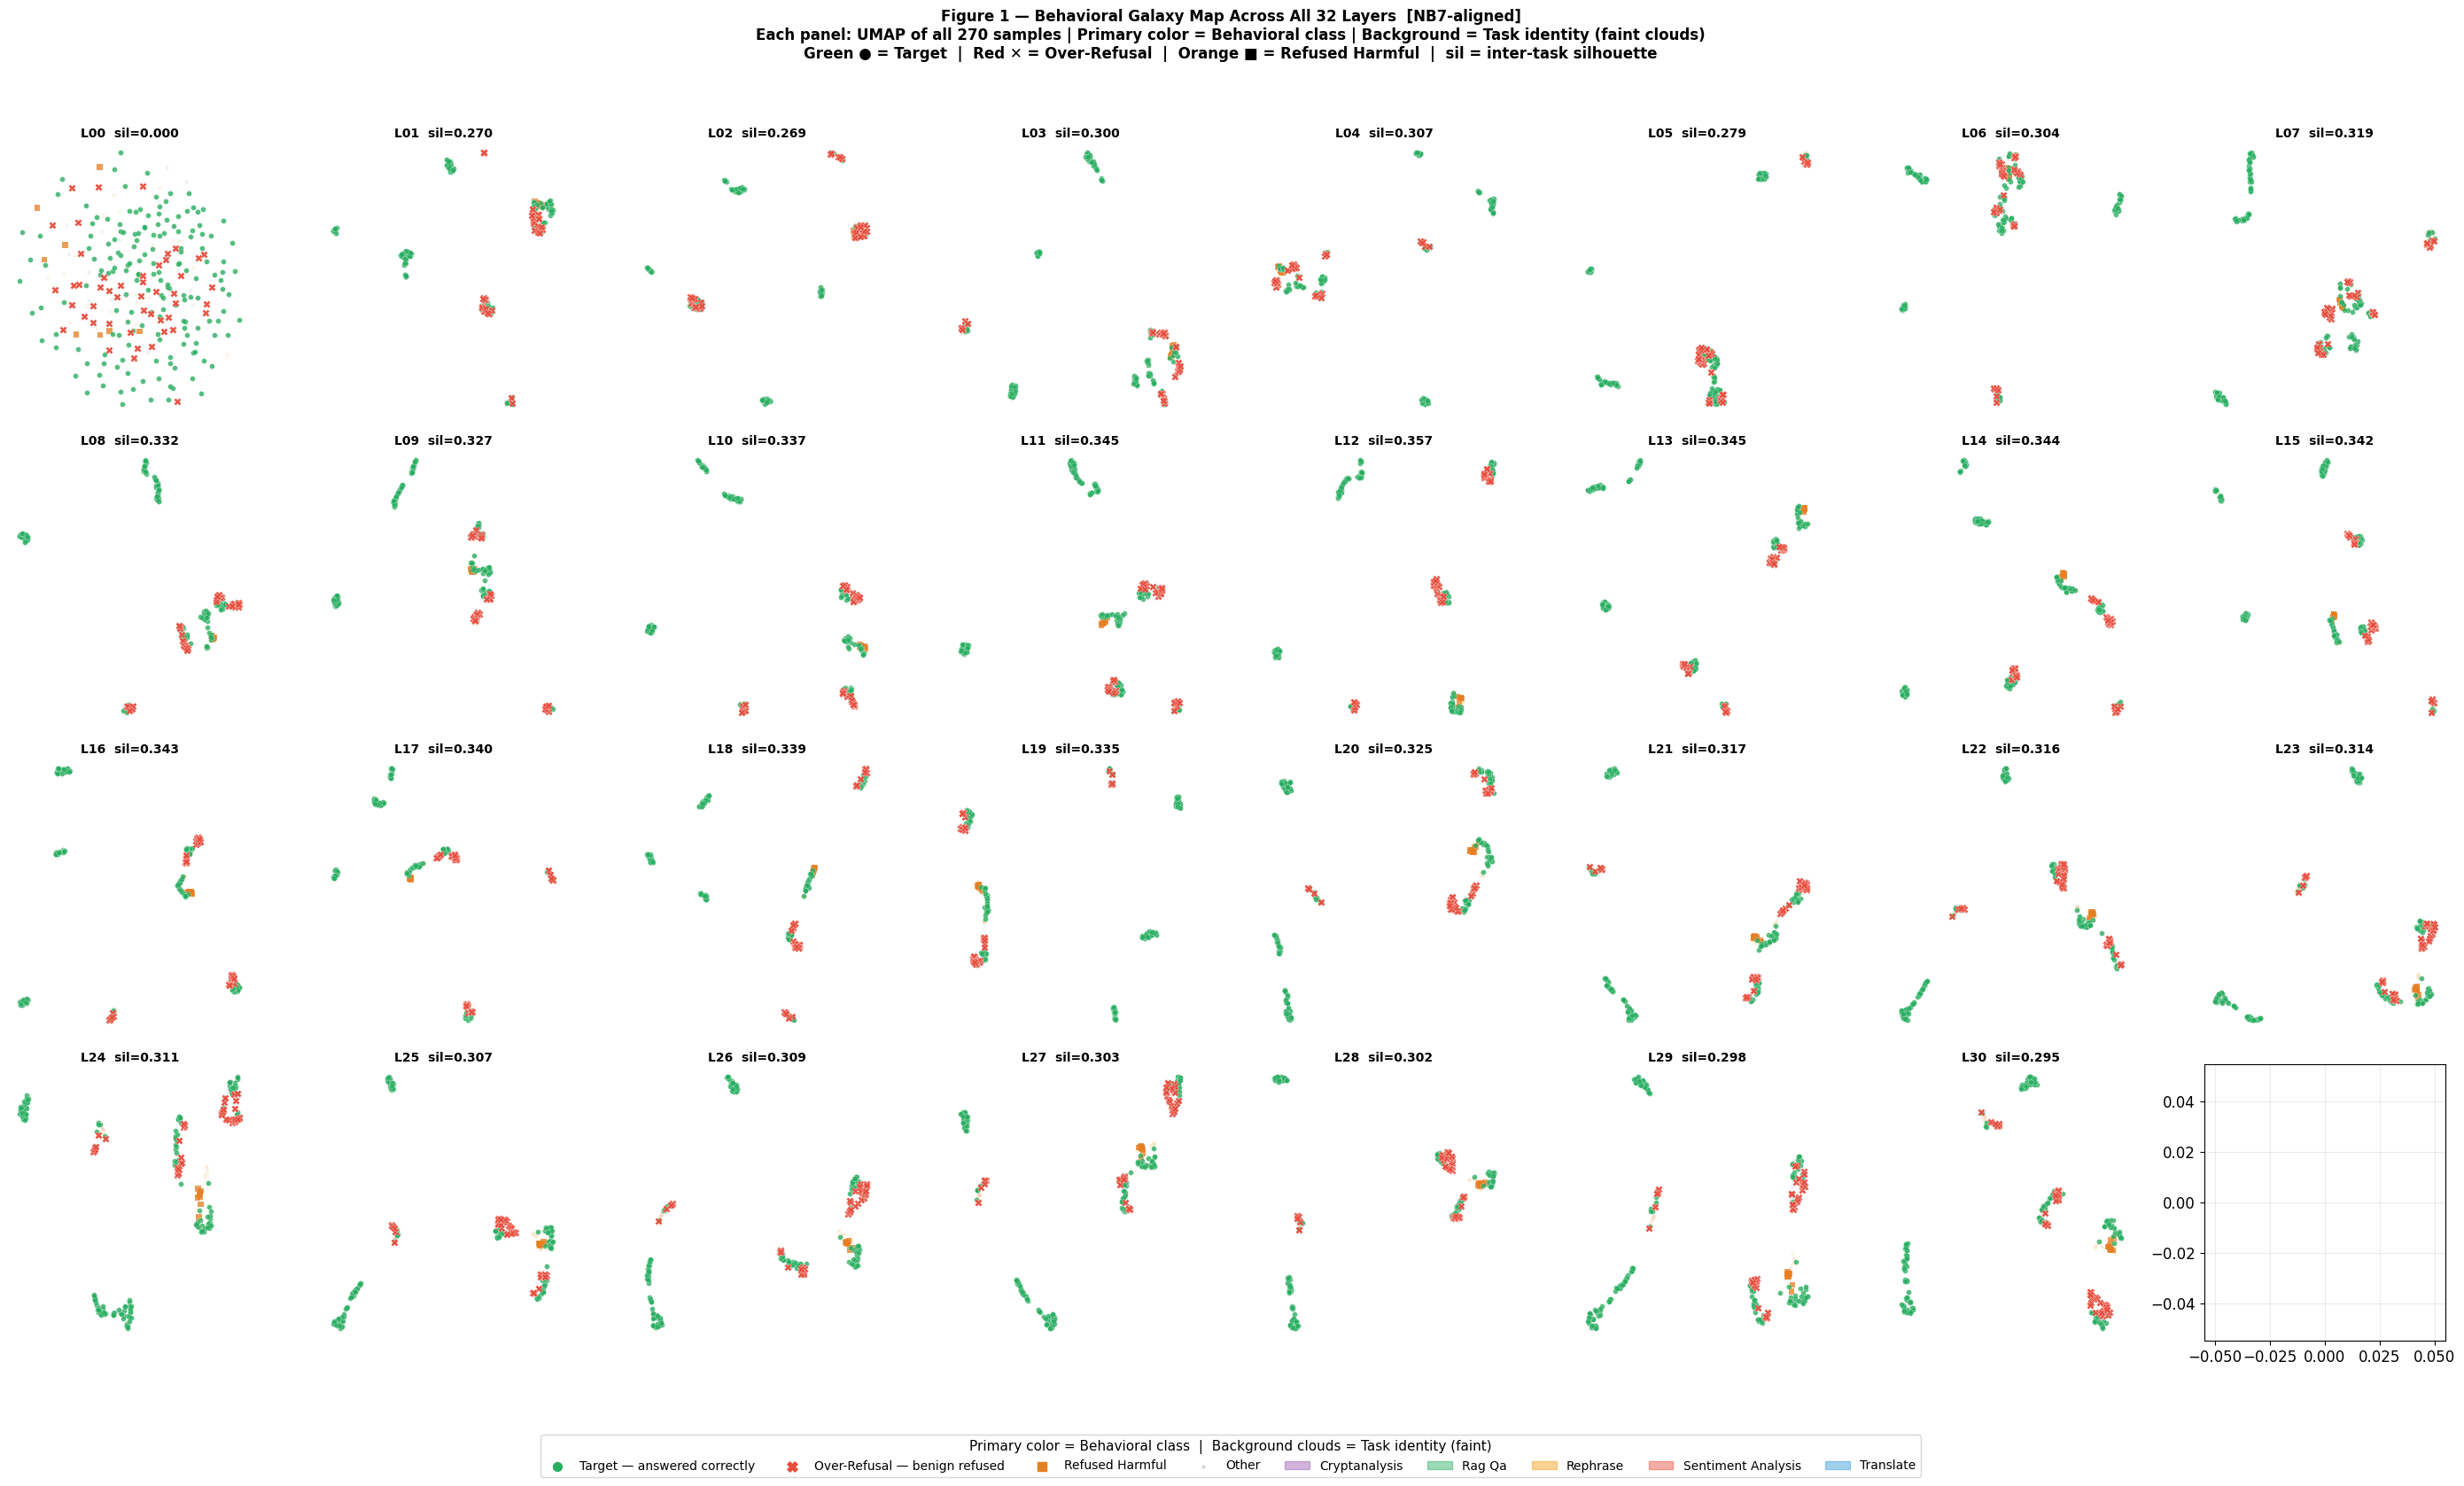

Saved: fig1_behavior_galaxy_grid.pdf

KEY: Note whether red X marks (over-refusal) appear WITHIN task-coloured clouds
     or cluster SEPARATELY from all task regions.
     Within = behavioral separation is task-conditioned (secondary to constellation structure)
     Separate = refusal is a global signal (Arditi single-direction approach is justified)


In [6]:
# Figure 1 — 32-Layer Behavioral Galaxy Grid  [NB7-aligned]
# Primary color = behavioral class | Background = task identity (faint)
# Directly shows whether over-refusal cases are globally separate or within task clusters.

BEH_COLORS_F1 = {
    'target':          '#27AE60',   # green
    'over_refusal':    '#E74C3C',   # red
    'refused_harmful': '#E67E22',   # orange
    'other':           '#BDC3C7',   # grey
}
BEH_ALPHA_F1 = {'target': 0.78, 'over_refusal': 0.95, 'refused_harmful': 0.75, 'other': 0.10}
BEH_SIZE_F1  = {'target': 18,   'over_refusal': 35,   'refused_harmful': 22,   'other': 5}
BEH_PLOT_ORDER_F1 = ['other', 'refused_harmful', 'target', 'over_refusal']

N_COLS, N_ROWS = 8, 4
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(28, 16))
axes_flat = axes.flatten()

for i, lname in enumerate(LAYER_NAMES):
    ax     = axes_flat[i]
    emb_2d = umap_2d[lname]
    sil    = task_sil_per_layer[lname]

    # Background: faint task-coloured clouds (constellation context)
    for task in ALL_TASKS:
        tmask = intended_task_labels == task
        ax.scatter(emb_2d[tmask, 0], emb_2d[tmask, 1],
                   c=TASK_COLORS[task], s=6, alpha=0.06, rasterized=True, zorder=1)

    # Foreground: behavior-coloured points
    for beh in BEH_PLOT_ORDER_F1:
        bmask = beh_labels == beh
        if bmask.sum() == 0:
            continue
        ax.scatter(
            emb_2d[bmask, 0], emb_2d[bmask, 1],
            c=BEH_COLORS_F1[beh],
            marker=BEH_MARKERS[beh],
            s=BEH_SIZE_F1[beh],
            alpha=BEH_ALPHA_F1[beh],
            linewidths=0.2,
            edgecolors='white' if beh in ('target', 'over_refusal') else 'none',
            rasterized=True, zorder=3,
        )

    sil_str = f'{sil:.3f}' if not np.isnan(sil) else 'N/A'
    ax.set_title(f'L{i:02d}  sil={sil_str}', fontsize=10, fontweight='bold', pad=2)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# Legends
beh_handles = [
    plt.scatter([], [], c=BEH_COLORS_F1['target'],          marker='o', s=50,
                label='Target — answered correctly'),
    plt.scatter([], [], c=BEH_COLORS_F1['over_refusal'],    marker='X', s=65,
                label='Over-Refusal — benign refused'),
    plt.scatter([], [], c=BEH_COLORS_F1['refused_harmful'], marker='s', s=45,
                label='Refused Harmful'),
    plt.scatter([], [], c=BEH_COLORS_F1['other'],           marker='.', s=20,
                label='Other', alpha=0.5),
]
task_bg_handles = [
    mpatches.Patch(color=TASK_COLORS[t], alpha=0.45,
                   label=t.replace('_', ' ').title())
    for t in ALL_TASKS
]
fig.legend(
    handles=beh_handles + task_bg_handles,
    loc='lower center', ncol=9, fontsize=10,
    frameon=True, bbox_to_anchor=(0.5, -0.02),
    title='Primary color = Behavioral class  |  Background clouds = Task identity (faint)',
    title_fontsize=11,
)
fig.suptitle(
    'Figure 1 — Behavioral Galaxy Map Across All 32 Layers  [NB7-aligned]\n'
    'Each panel: UMAP of all 270 samples | Primary color = Behavioral class | '
    'Background = Task identity (faint clouds)\n'
    'Green ● = Target  |  Red ✕ = Over-Refusal  |  Orange ■ = Refused Harmful  |  '
    'sil = inter-task silhouette',
    fontsize=12, fontweight='bold', y=1.02,
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('fig1_behavior_galaxy_grid.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig1_behavior_galaxy_grid.pdf')
print()
print('KEY: Note whether red X marks (over-refusal) appear WITHIN task-coloured clouds')
print('     or cluster SEPARATELY from all task regions.')
print('     Within = behavioral separation is task-conditioned (secondary to constellation structure)')
print('     Separate = refusal is a global signal (Arditi single-direction approach is justified)')

In [7]:
# Section 1 Findings — Printed Summary
sil_vals  = [task_sil_per_layer[l] for l in LAYER_NAMES]
early_sil = np.nanmean(sil_vals[:8])
mid_sil   = np.nanmean(sil_vals[8:20])
late_sil  = np.nanmean(sil_vals[20:])
peak_sil_idx = int(np.nanargmax(sil_vals))
min_sil_idx  = int(np.nanargmin(sil_vals))

print('=' * 68)
print('SECTION 1 FINDINGS — CONSTELLATION FORMATION (INTER-TASK SILHOUETTE)')
print('=' * 68)
print(f'  Silhouette score measures how well 5 task clusters are separated.')
print(f'  Range: -1 (wrong cluster) to +1 (tight, well-separated clusters).')
print()
print(f'  Phase averages:')
print(f'    Early layers (L00-L07) mean silhouette : {early_sil:+.3f}')
print(f'    Mid   layers (L08-L19) mean silhouette : {mid_sil:+.3f}')
print(f'    Late  layers (L20-L31) mean silhouette : {late_sil:+.3f}')
print()
print(f'  Per-layer extremes:')
print(f'    Peak separation : L{peak_sil_idx:02d} = {sil_vals[peak_sil_idx]:.3f}')
print(f'    Least separated : L{min_sil_idx:02d}  = {sil_vals[min_sil_idx]:.3f}')
print()
print(f'  Full layer-by-layer silhouette scores:')
for i in range(0, N_LAYERS, 4):
    row = '  '.join(f'L{i+j:02d}:{sil_vals[i+j]:+.3f}' for j in range(4) if i+j < N_LAYERS)
    print(f'    {row}')
print()
if mid_sil > early_sil:
    print(f'  INTERPRETATION: Mid-layer silhouette ({mid_sil:.3f}) exceeds early-layer ({early_sil:.3f}),')
    print(f'  confirming that task constellations form during mid-layer processing.')
    delta = mid_sil - early_sil
    print(f'  The {delta:.3f} gain quantifies constellation formation strength.')
else:
    print(f'  NOTE: Silhouette pattern is non-standard — inspect Figure 1 for visual structure.')
print('=' * 68)

SECTION 1 FINDINGS — CONSTELLATION FORMATION (INTER-TASK SILHOUETTE)
  Silhouette score measures how well 5 task clusters are separated.
  Range: -1 (wrong cluster) to +1 (tight, well-separated clusters).

  Phase averages:
    Early layers (L00-L07) mean silhouette : +0.256
    Mid   layers (L08-L19) mean silhouette : +0.341
    Late  layers (L20-L31) mean silhouette : +0.309

  Per-layer extremes:
    Peak separation : L12 = 0.357
    Least separated : L00  = 0.000

  Full layer-by-layer silhouette scores:
    L00:+0.000  L01:+0.270  L02:+0.269  L03:+0.300
    L04:+0.307  L05:+0.279  L06:+0.304  L07:+0.319
    L08:+0.332  L09:+0.327  L10:+0.337  L11:+0.345
    L12:+0.357  L13:+0.345  L14:+0.344  L15:+0.342
    L16:+0.343  L17:+0.340  L18:+0.339  L19:+0.335
    L20:+0.325  L21:+0.317  L22:+0.316  L23:+0.314
    L24:+0.311  L25:+0.307  L26:+0.309  L27:+0.303
    L28:+0.302  L29:+0.298  L30:+0.295

  INTERPRETATION: Mid-layer silhouette (0.341) exceeds early-layer (0.256),
  confirming 

---
## Figure 1b — Dual Galaxy Map at Peak Constellation Layer  [NB7 Cell 35 analogue]

**The definitive visual answer to: "where do over-refusal cases sit?"**

At the peak-constellation layer (automatically determined from the separation ratio), the same UMAP coordinate system is shown twice side by side:

- **LEFT:** Color = task identity. Shows that 5 tasks occupy geometrically distinct regions — the constellation structure.
- **RIGHT:** Color = behavioral class (green = target, red = over-refusal, orange = refused-harmful). Task region labels shown faint for orientation.

**What to look for in the RIGHT panel:**
- Red ✕ marks (over-refusal) scattered *inside* task-coloured zones → behavioral separation is a within-cluster signal, secondary to task identity. A single global refusal direction is geometrically lossy.
- Red ✕ marks forming a *separate cluster* away from all task zones → refusal geometry is task-independent, and Arditi's universal direction is plausible.

No extra UMAP fitting — uses the precomputed `umap_2d` at the peak layer.

Dual Galaxy Map at peak constellation layer: L01 (sep ratio = 2.380, inter-task silhouette = 0.270)


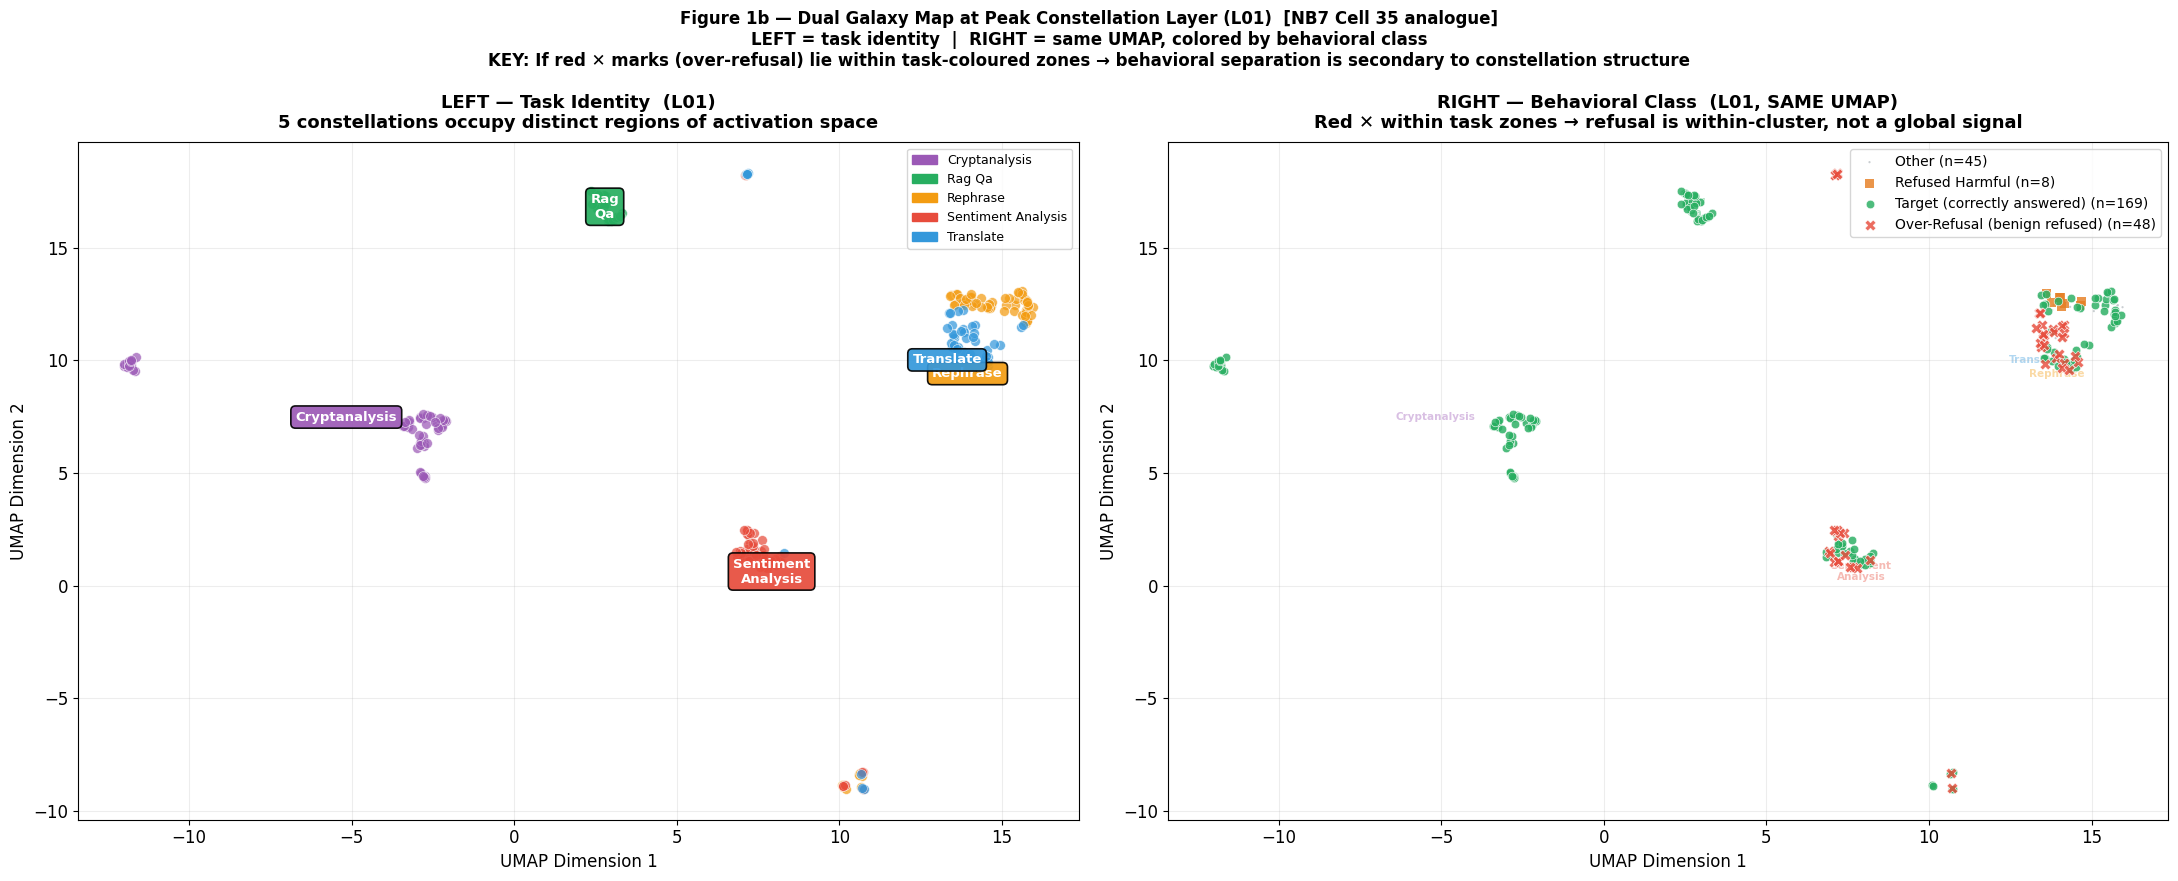

Saved: fig1b_dual_galaxy_map.pdf


In [9]:
# Figure 1b — Dual Galaxy Map at Peak Constellation Layer  [NB7 Cell 35 analogue]
# Same UMAP shown twice: LEFT = task identity, RIGHT = behavioral class.
# Uses the precomputed umap_2d at the peak separation layer — no extra UMAP fitting.

# sep_vals may not be defined yet if Figure 2 hasn't run — compute from precomputed dict
_sep_vals = [separation_ratio[l] for l in LAYER_NAMES]

peak_sep_idx_gal = int(np.argmax(_sep_vals))
gal_lname        = LAYER_NAMES[peak_sep_idx_gal]
umap_gal         = umap_2d[gal_lname]       # (270, 2) — already precomputed

print(f'Dual Galaxy Map at peak constellation layer: L{peak_sep_idx_gal:02d} '
      f'(sep ratio = {_sep_vals[peak_sep_idx_gal]:.3f}, '
      f'inter-task silhouette = {task_sil_per_layer[gal_lname]:.3f})')

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# ── LEFT: Task identity ───────────────────────────────────────────────────────
ax = axes[0]
for task in ALL_TASKS:
    mask  = intended_task_labels == task
    color = TASK_COLORS[task]
    ax.scatter(umap_gal[mask, 0], umap_gal[mask, 1],
               c=color, s=50, alpha=0.72,
               edgecolors='white', linewidth=0.5, zorder=3)
    cx, cy = umap_gal[mask, 0].mean(), umap_gal[mask, 1].mean()
    ax.annotate(task.replace('_', '\n').title(), (cx, cy),
                fontsize=9.5, fontweight='bold', color='white',
                ha='center', va='center', zorder=6,
                bbox=dict(boxstyle='round,pad=0.35', facecolor=color,
                          alpha=0.92, edgecolor='black', linewidth=1.2))

ax.legend(handles=[mpatches.Patch(color=TASK_COLORS[t], label=t.replace('_', ' ').title())
                   for t in ALL_TASKS],
          loc='upper right', fontsize=9, frameon=True)
ax.set_title(
    f'LEFT — Task Identity  (L{peak_sep_idx_gal:02d})\n'
    '5 constellations occupy distinct regions of activation space',
    fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('UMAP Dimension 1', fontsize=12)
ax.set_ylabel('UMAP Dimension 2', fontsize=12)
ax.grid(True, alpha=0.22)

# ── RIGHT: Behavioral class — exact same UMAP ─────────────────────────────────
ax = axes[1]

for beh, color, size, zord, label_str in [
    ('other',          '#BDC3C7', 10, 1, 'Other'),
    ('refused_harmful','#E67E22', 42, 2, 'Refused Harmful'),
    ('target',         '#27AE60', 38, 3, 'Target (correctly answered)'),
    ('over_refusal',   '#E74C3C', 62, 4, 'Over-Refusal (benign refused)'),
]:
    bmask = beh_labels == beh
    if bmask.sum() == 0:
        continue
    ax.scatter(umap_gal[bmask, 0], umap_gal[bmask, 1],
               c=color, marker=BEH_MARKERS[beh], s=size, alpha=0.82,
               edgecolors='white' if beh in ('target', 'over_refusal') else 'none',
               linewidth=0.5, label=f'{label_str} (n={bmask.sum()})', zorder=zord)

# Faint task region labels for orientation
for task in ALL_TASKS:
    tmask = intended_task_labels == task
    cx, cy = umap_gal[tmask, 0].mean(), umap_gal[tmask, 1].mean()
    ax.text(cx, cy, task.replace('_', '\n').title(),
            fontsize=7.5, ha='center', va='center',
            color=TASK_COLORS[task], fontweight='bold', alpha=0.38, zorder=1)

ax.legend(fontsize=10, frameon=True, loc='upper right')
ax.set_title(
    f'RIGHT — Behavioral Class  (L{peak_sep_idx_gal:02d}, SAME UMAP)\n'
    'Red ✕ within task zones → refusal is within-cluster, not a global signal',
    fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('UMAP Dimension 1', fontsize=12)
ax.set_ylabel('UMAP Dimension 2', fontsize=12)
ax.grid(True, alpha=0.22)

fig.suptitle(
    f'Figure 1b — Dual Galaxy Map at Peak Constellation Layer (L{peak_sep_idx_gal:02d})  '
    f'[NB7 Cell 35 analogue]\n'
    'LEFT = task identity  |  RIGHT = same UMAP, colored by behavioral class\n'
    'KEY: If red ✕ marks (over-refusal) lie within task-coloured zones → '
    'behavioral separation is secondary to constellation structure',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1b_dual_galaxy_map.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig1b_dual_galaxy_map.pdf')

---
## Figure 1c — Per-Task Target vs. Over-Refusal Separation  [NB7 Cell 32 analogue]

**The scale comparison that matters:** Is the within-task behavioral gap (target ↔ over-refusal centroid distance) large or small relative to the inter-task gap?

- **Panel 1 — Centroid distance:** Solid lines = within-task target↔over-refusal L2 distance per task, across all 32 layers. Dashed black = mean inter-task centroid distance (the scale reference from Section 2). If the solid lines are far below the dashed line, over-refusal cases are geometrically much closer to their task's target samples than to any other task.

- **Panel 2 — Within-task silhouette:** Same as Section 3's crystallization heatmap but displayed as line plots for direct cross-task comparison. Values near 0 = refused and answered samples overlap in that task's cluster. Values above 0.3 = meaningful separation.

**Why this grounds the NB7 narrative:** If solid << dashed throughout, the behavioral signal is secondary to task identity — Arditi's single direction must sacrifice task-specific structure.

Tasks with ≥2 target and ≥2 over-refusal samples: ['sentiment_analysis', 'translate']
  sentiment_analysis    : target n=32  OR n=20  max gap=9.3 @ L14  (inter-task mean @ L14 = 22.0)
  translate             : target n=23  OR n=28  max gap=8.4 @ L20  (inter-task mean @ L20 = 18.8)


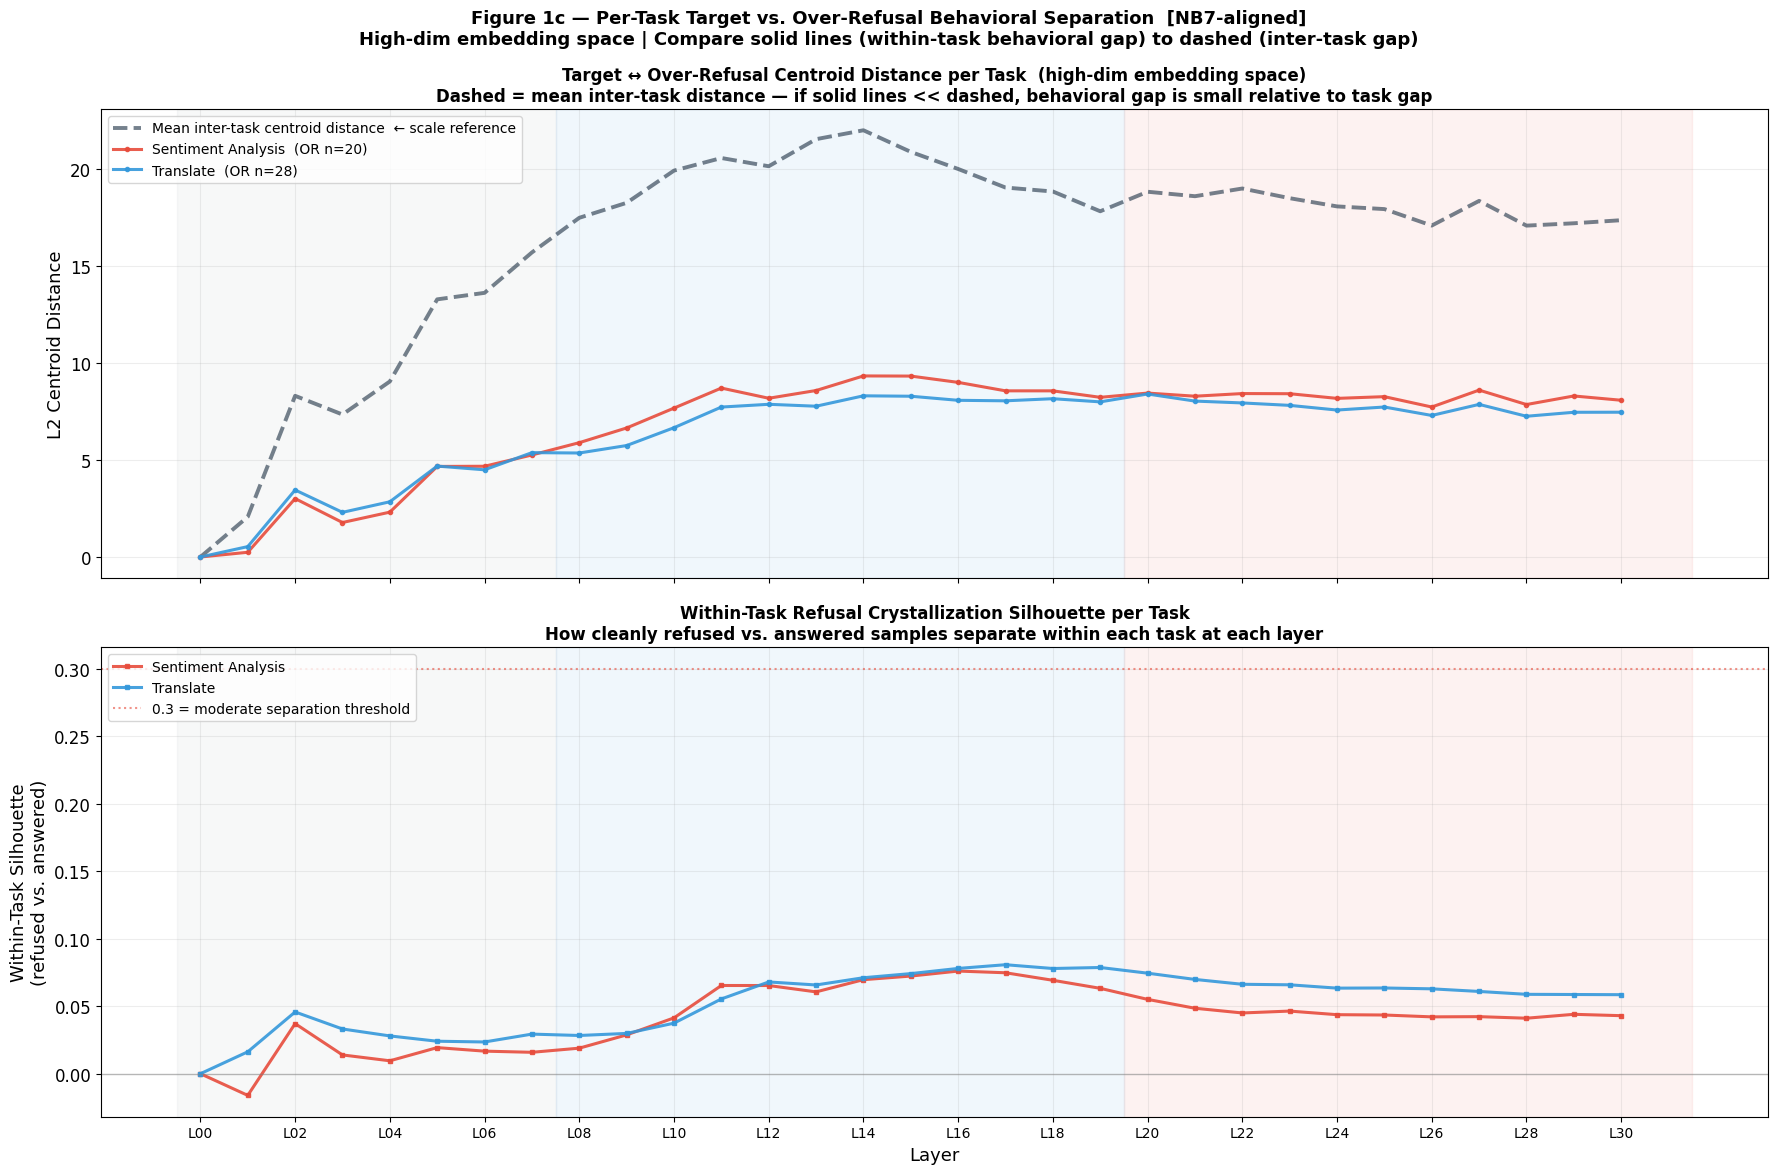

Saved: fig1c_per_task_behavioral_separation.pdf

INTERPRETATION GUIDE:
  solid << dashed  →  over-refusal cases are geometrically closer to their own
                       task's target samples than to any other task's samples.
                       Refusal is within-cluster; Arditi loses task-specific info.
  solid ≈ dashed   →  over-refusal cases drift as far from target as they drift
                       from other tasks. A global refusal direction is plausible.


In [10]:
# Figure 1c — Per-Task Target vs. Over-Refusal Separation  [NB7 Cell 32 analogue]
# All metrics computed in HIGH-DIMENSIONAL embedding space — no UMAP, no projection artifacts.
# Panel 1: within-task centroid distance vs. mean inter-task distance (scale reference)
# Panel 2: within-task silhouette (refused vs. answered) per task

TASKS_WITH_OR_13a = [
    t for t in ALL_TASKS
    if (TARGET_MASK       & (intended_task_labels == t)).sum() >= 2 and
       (OVER_REFUSAL_MASK & (intended_task_labels == t)).sum() >= 2
]
print(f'Tasks with ≥2 target and ≥2 over-refusal samples: {TASKS_WITH_OR_13a}')

layer_nums     = list(range(N_LAYERS))
inter_vals_ref = [inter_centroid_dist[l] for l in LAYER_NAMES]   # already precomputed

# ── Compute target↔over-refusal centroid distance per task per layer ──────────
cdist_data = {}
cryst_data = {}

for task in TASKS_WITH_OR_13a:
    tmask    = intended_task_labels == task
    tgt_mask = TARGET_MASK & tmask
    or_mask  = OVER_REFUSAL_MASK & tmask
    n_tgt, n_or = tgt_mask.sum(), or_mask.sum()

    dists  = []
    crysts = []
    for lname in LAYER_NAMES:
        emb   = embeddings_np[lname]
        c_tgt = emb[tgt_mask].mean(axis=0)
        c_or  = emb[or_mask].mean(axis=0)
        dists.append(float(np.linalg.norm(c_tgt - c_or)))
        crysts.append(cryst_sil.get((task, lname), np.nan))

    cdist_data[task] = dists
    cryst_data[task] = crysts
    peak_l = int(np.argmax(dists))
    print(f'  {task:<22}: target n={n_tgt}  OR n={n_or}  '
          f'max gap={max(dists):.1f} @ L{peak_l:02d}  '
          f'(inter-task mean @ L{peak_l:02d} = {inter_vals_ref[peak_l]:.1f})')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)
TASK_LINE_COLORS = [TASK_COLORS[t] for t in TASKS_WITH_OR_13a]

# Panel 1: Centroid distance
ax = axes[0]
ax.plot(layer_nums, inter_vals_ref, color='#2C3E50', lw=2.8, ls='--', alpha=0.65, zorder=2,
        label='Mean inter-task centroid distance  ← scale reference')
for task, color in zip(TASKS_WITH_OR_13a, TASK_LINE_COLORS):
    n_or = (OVER_REFUSAL_MASK & (intended_task_labels == task)).sum()
    ax.plot(layer_nums, cdist_data[task], color=color, lw=2.2, marker='o', ms=3,
            label=f'{task.replace("_"," ").title()}  (OR n={n_or})', alpha=0.90, zorder=3)

ax.axvspan(-0.5,  7.5, alpha=0.07, color='#95A5A6')
ax.axvspan( 7.5, 19.5, alpha=0.07, color='#3498DB')
ax.axvspan(19.5, 31.5, alpha=0.07, color='#E74C3C')
ax.set_ylabel('L2 Centroid Distance', fontsize=13)
ax.set_title(
    'Target ↔ Over-Refusal Centroid Distance per Task  (high-dim embedding space)\n'
    'Dashed = mean inter-task distance — if solid lines << dashed, '
    'behavioral gap is small relative to task gap',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=10, frameon=True, loc='upper left')
ax.grid(True, alpha=0.22)

# Panel 2: Within-task silhouette
ax = axes[1]
for task, color in zip(TASKS_WITH_OR_13a, TASK_LINE_COLORS):
    ax.plot(layer_nums, cryst_data[task], color=color, lw=2.2, marker='s', ms=3,
            label=task.replace('_', ' ').title(), alpha=0.90)
ax.axhline(0.0, color='grey',    ls='-',  lw=1.0, alpha=0.5)
ax.axhline(0.3, color='#E74C3C', ls=':',  lw=1.5, alpha=0.6,
           label='0.3 = moderate separation threshold')

ax.axvspan(-0.5,  7.5, alpha=0.07, color='#95A5A6')
ax.axvspan( 7.5, 19.5, alpha=0.07, color='#3498DB')
ax.axvspan(19.5, 31.5, alpha=0.07, color='#E74C3C')
ax.set_ylabel('Within-Task Silhouette\n(refused vs. answered)', fontsize=13)
ax.set_xlabel('Layer', fontsize=13)
ax.set_title(
    'Within-Task Refusal Crystallization Silhouette per Task\n'
    'How cleanly refused vs. answered samples separate within each task at each layer',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=10, frameon=True, loc='upper left')
ax.grid(True, alpha=0.22)
ax.set_xticks(list(range(0, N_LAYERS, 2)))
ax.set_xticklabels([f'L{i:02d}' for i in range(0, N_LAYERS, 2)], fontsize=10)

fig.suptitle(
    'Figure 1c — Per-Task Target vs. Over-Refusal Behavioral Separation  [NB7-aligned]\n'
    'High-dim embedding space | Compare solid lines (within-task behavioral gap) '
    'to dashed (inter-task gap)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1c_per_task_behavioral_separation.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig1c_per_task_behavioral_separation.pdf')
print()
print('INTERPRETATION GUIDE:')
print('  solid << dashed  →  over-refusal cases are geometrically closer to their own')
print('                       task\'s target samples than to any other task\'s samples.')
print('                       Refusal is within-cluster; Arditi loses task-specific info.')
print('  solid ≈ dashed   →  over-refusal cases drift as far from target as they drift')
print('                       from other tasks. A global refusal direction is plausible.')

---
## Section 2 — Quantitative Constellation Profile (All 32 Layers)

Four complementary metrics across all layers, computed on the full embedding space:

1. **Inter-task centroid distance** — Mean pairwise L2 distance between the 5 task centroids. High = constellations are far apart in space.
2. **Intra-task spread** — Mean distance of samples from their task centroid. Low = constellations are compact and tight.
3. **Separation ratio** (inter / intra) — The headline metric. High = well-separated *and* compact constellations. This is the cleanest single indicator of constellation quality.
4. **Inter-task silhouette** — Classification-based: do samples lie closer to their own task centroid than to any other? (From Section 1, repeated here for direct comparison.)

Together these four metrics confirm and quantify what Figure 1 shows visually.

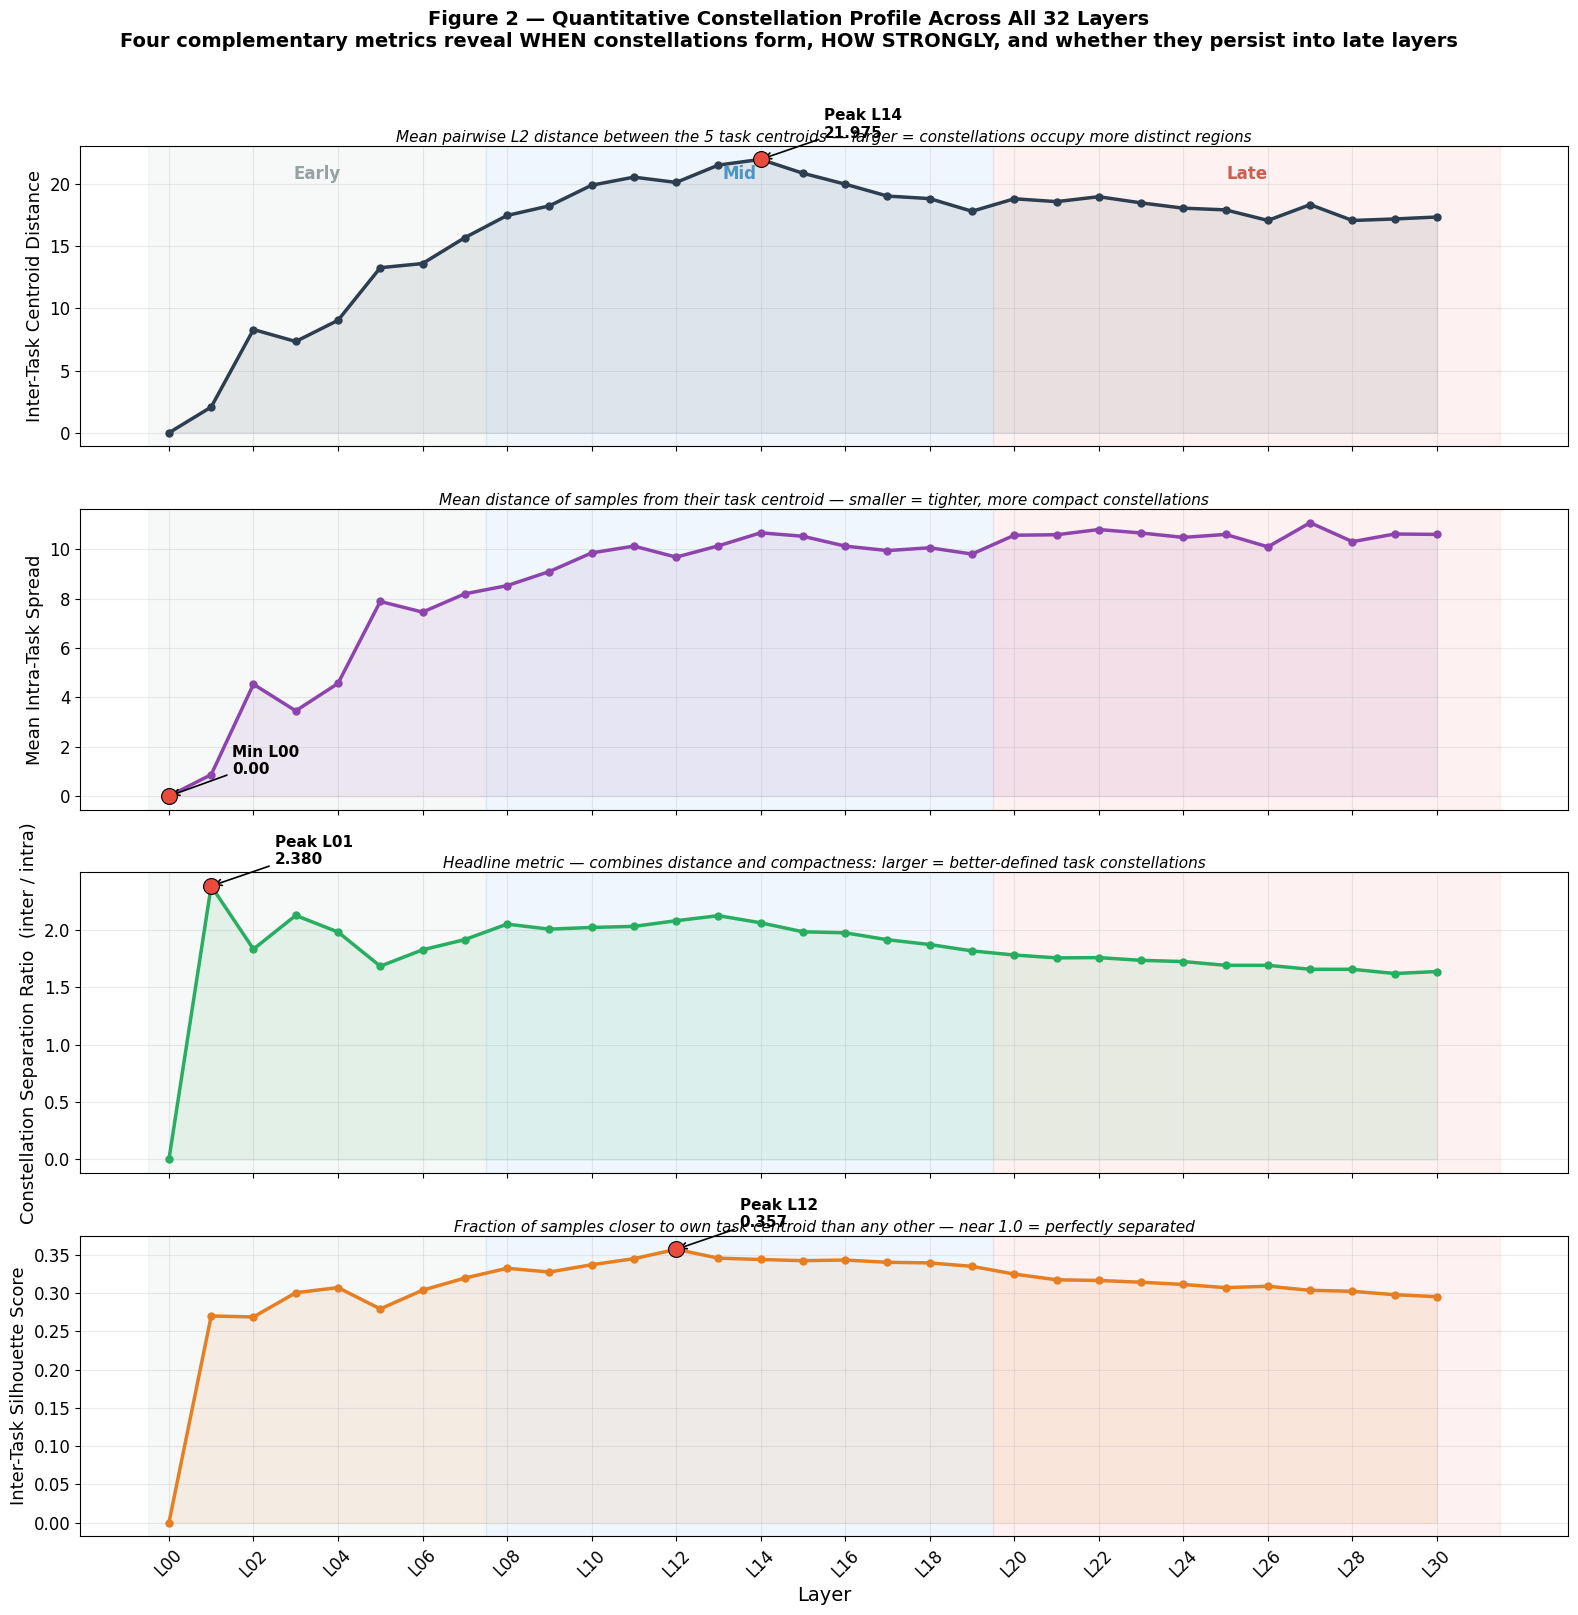

Saved: fig2_layer_profile_metrics.pdf


In [11]:
# Figure 2 — 4-panel quantitative layer profile
layer_nums = list(range(N_LAYERS))
inter_vals = [inter_centroid_dist[l] for l in LAYER_NAMES]
intra_vals = [intra_task_spread[l]   for l in LAYER_NAMES]
sep_vals   = [separation_ratio[l]    for l in LAYER_NAMES]
sil_vals   = [task_sil_per_layer[l]  for l in LAYER_NAMES]

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)
xtick_pos    = list(range(0, N_LAYERS, 2))
xtick_labels = [f'L{i:02d}' for i in xtick_pos]

panel_data = [
    (inter_vals, '#2C3E50', 'Inter-Task Centroid Distance',
     'Mean pairwise L2 distance between the 5 task centroids — larger = constellations occupy more distinct regions'),
    (intra_vals, '#8E44AD', 'Mean Intra-Task Spread',
     'Mean distance of samples from their task centroid — smaller = tighter, more compact constellations'),
    (sep_vals,   '#27AE60', 'Constellation Separation Ratio  (inter / intra)',
     'Headline metric — combines distance and compactness: larger = better-defined task constellations'),
    (sil_vals,   '#E67E22', 'Inter-Task Silhouette Score',
     'Fraction of samples closer to own task centroid than any other — near 1.0 = perfectly separated'),
]

for ax, (vals, color, ylabel, subtitle) in zip(axes, panel_data):
    vals_clean = [v if not np.isnan(v) else np.nan for v in vals]
    ax.plot(layer_nums, vals_clean, color=color, lw=2.5, marker='o', ms=5, zorder=3)
    ax.fill_between(layer_nums, vals_clean, alpha=0.10, color=color)

    ax.axvspan(-0.5,  7.5, alpha=0.07, color='#95A5A6')
    ax.axvspan( 7.5, 19.5, alpha=0.07, color='#3498DB')
    ax.axvspan(19.5, 31.5, alpha=0.07, color='#E74C3C')

    # Annotate peak
    valid = [(i, v) for i, v in enumerate(vals_clean) if v is not None and not np.isnan(v)]
    if valid:
        if ylabel.startswith('Mean Intra'):   # lower is better for intra
            pk_i, pk_v = min(valid, key=lambda x: x[1])
            label_txt = f'Min L{pk_i:02d}\n{pk_v:.2f}'
        else:
            pk_i, pk_v = max(valid, key=lambda x: x[1])
            label_txt = f'Peak L{pk_i:02d}\n{pk_v:.3f}'
        ax.scatter([pk_i], [pk_v], color='#E74C3C', s=130, zorder=5, edgecolors='black', linewidths=0.8)
        offset = (max(v for _, v in valid) - min(v for _, v in valid)) * 0.08
        ax.annotate(label_txt, xy=(pk_i, pk_v), xytext=(pk_i + 1.5, pk_v + offset),
                    fontsize=11, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(subtitle, fontsize=11, style='italic', pad=3)
    ax.grid(True, alpha=0.25)

axes[-1].set_xticks(xtick_pos)
axes[-1].set_xticklabels(xtick_labels, rotation=45, fontsize=12)
axes[-1].set_xlabel('Layer', fontsize=14)

# Phase labels on top panel
top_ax = axes[0]
y_top  = max(v for v in inter_vals if not np.isnan(v)) * 0.98
for xc, lbl, c in [(3.5,'Early','#7F8C8D'), (13.5,'Mid','#2980B9'), (25.5,'Late','#C0392B')]:
    top_ax.text(xc, y_top, lbl, ha='center', va='top', fontsize=12,
                color=c, fontweight='bold', alpha=0.8)

fig.suptitle(
    'Figure 2 — Quantitative Constellation Profile Across All 32 Layers\n'
    'Four complementary metrics reveal WHEN constellations form, HOW STRONGLY, '
    'and whether they persist into late layers',
    fontsize=14, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.savefig('fig2_layer_profile_metrics.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig2_layer_profile_metrics.pdf')

In [12]:
# Section 2 Findings — Numeric Summary
peak_sep_idx   = int(np.argmax(sep_vals))
peak_sil_idx   = int(np.nanargmax(sil_vals))
min_intra_idx  = int(np.argmin(intra_vals))
peak_inter_idx = int(np.argmax(inter_vals))

# Safe key layers — only include indices that exist
KEY_LAYERS_PRINT = [i for i in [0, 4, 8, 12, 15, 18, 20, 24, 28, N_LAYERS - 1] if i < N_LAYERS]
KEY_LAYERS_PRINT = sorted(set(KEY_LAYERS_PRINT))   # deduplicate in case N_LAYERS-1 duplicates

print('=' * 68)
print('SECTION 2 FINDINGS — LAYER PROFILE METRICS (COMPLETE TABLE)')
print('=' * 68)
print(f'  {"Layer":<8} {"Inter-centroid":>16} {"Intra-spread":>14} {"Sep-Ratio":>11} {"Sil":>8}')
print(f'  {"-"*60}')
for i in KEY_LAYERS_PRINT:
    star = ' <-- peak separation' if i == peak_sep_idx else ''
    print(f'  L{i:02d}     {inter_vals[i]:>16.2f} {intra_vals[i]:>14.2f} '
          f'{sep_vals[i]:>11.3f} {sil_vals[i]:>8.3f}{star}')
print()
print(f'  Total layers in data            : {N_LAYERS}')
print(f'  Peak constellation sep ratio    : L{peak_sep_idx:02d} = {sep_vals[peak_sep_idx]:.3f}')
print(f'  Peak inter-task silhouette      : L{peak_sil_idx:02d} = {sil_vals[peak_sil_idx]:.3f}')
print(f'  Minimum intra-task spread       : L{min_intra_idx:02d} = {intra_vals[min_intra_idx]:.2f}')
print(f'  Maximum inter-task distance     : L{peak_inter_idx:02d} = {inter_vals[peak_inter_idx]:.2f}')
print()
if abs(peak_sep_idx - peak_sil_idx) <= 3:
    print(f'  Both separation ratio and silhouette peak near L{peak_sep_idx:02d}-L{peak_sil_idx:02d},')
    print(f'  confirming this as the primary constellation crystallization window.')
else:
    print(f'  Separation ratio peaks at L{peak_sep_idx:02d}, silhouette at L{peak_sil_idx:02d}.')
    print(f'  The {abs(peak_sep_idx - peak_sil_idx)}-layer gap suggests a staggered formation process.')
print('=' * 68)


SECTION 2 FINDINGS — LAYER PROFILE METRICS (COMPLETE TABLE)
  Layer      Inter-centroid   Intra-spread   Sep-Ratio      Sil
  ------------------------------------------------------------
  L00                 0.00           0.00       0.000    0.000
  L04                 9.04           4.57       1.979    0.307
  L08                17.47           8.53       2.048    0.332
  L12                20.12           9.68       2.078    0.357
  L15                20.86          10.53       1.981    0.342
  L18                18.82          10.06       1.870    0.339
  L20                18.81          10.57       1.779    0.325
  L24                18.05          10.48       1.722    0.311
  L28                17.06          10.31       1.655    0.302
  L30                17.34          10.61       1.635    0.295

  Total layers in data            : 31
  Peak constellation sep ratio    : L01 = 2.380
  Peak inter-task silhouette      : L12 = 0.357
  Minimum intra-task spread       : L00 = 0.00


---
## Section 3 — Within-Task Refusal Crystallization

Sections 1–2 established that tasks separate into distinct constellations. Now the question is finer: **within each task's constellation, when does the model commit to a refusal vs. non-refusal decision?**

This is measured as the **within-task silhouette score for binary refusal classification** — computed separately for each task at each layer, using only the samples belonging to that task. A high score at layer L means: at that layer, the refused vs. answered samples within Task T are clearly geometrically distinct — the model has "crystallized" its refusal decision for that task.

**Key questions:**
- Do all tasks crystallize at the same layer, or is crystallization staggered?
- Does crystallization layer correlate with the overall constellation peak?
- Which tasks are early crystallizers vs. late crystallizers?

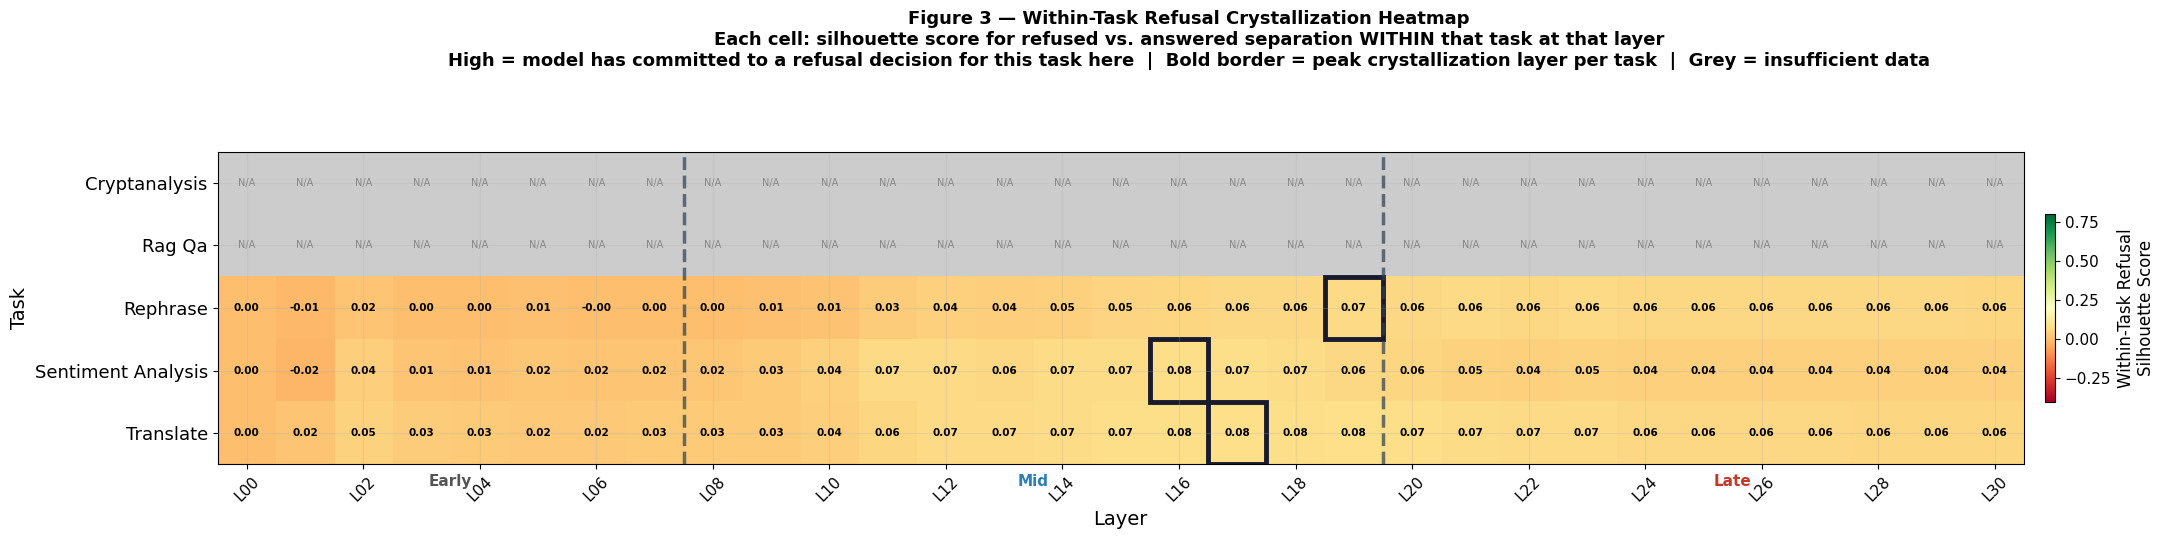

Saved: fig3_crystallization_heatmap.pdf


In [13]:
# Figure 3 — Within-Task Refusal Crystallization Heatmap
cryst_matrix = np.full((len(ALL_TASKS), N_LAYERS), np.nan)
for i, task in enumerate(ALL_TASKS):
    for j, lname in enumerate(LAYER_NAMES):
        cryst_matrix[i, j] = cryst_sil.get((task, lname), np.nan)

# Mask NaN for display
cryst_display = np.where(np.isnan(cryst_matrix), -1.0, cryst_matrix)

fig, ax = plt.subplots(figsize=(24, 5))
cmap = plt.cm.RdYlGn.copy()
cmap.set_under('#CCCCCC')   # grey for NaN / insufficient data

im = ax.imshow(cryst_display, cmap=cmap, vmin=-0.4, vmax=0.8,
               aspect='auto', interpolation='nearest')

# Annotate each cell with the value
for i in range(len(ALL_TASKS)):
    for j in range(N_LAYERS):
        val = cryst_matrix[i, j]
        if np.isnan(val):
            ax.text(j, i, 'N/A', ha='center', va='center', fontsize=7, color='#888')
        else:
            color = 'white' if abs(val) > 0.4 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7.5,
                    fontweight='bold', color=color)

# Mark peak per task with bold border
peak_layers = {}
for i, task in enumerate(ALL_TASKS):
    row = cryst_matrix[i]
    if not np.all(np.isnan(row)):
        pk_j = int(np.nanargmax(row))
        peak_layers[task] = (pk_j, float(np.nanmax(row)))
        rect = plt.Rectangle((pk_j - 0.5, i - 0.5), 1, 1,
                               fill=False, edgecolor='#1A1A2E', linewidth=3.5)
        ax.add_patch(rect)

# Phase boundary lines
for x in [7.5, 19.5]:
    ax.axvline(x, color='#2C3E50', lw=2.5, ls='--', alpha=0.7)

# Phase labels
y_lbl = len(ALL_TASKS) - 0.1
for xc, lbl, c in [(3.5,'Early','#555'), (13.5,'Mid','#2980B9'), (25.5,'Late','#C0392B')]:
    ax.text(xc, y_lbl, lbl, ha='center', va='bottom', fontsize=11, color=c, fontweight='bold')

ax.set_yticks(range(len(ALL_TASKS)))
ax.set_yticklabels([t.replace('_', ' ').title() for t in ALL_TASKS], fontsize=13)
ax.set_xticks(range(0, N_LAYERS, 2))
ax.set_xticklabels([f'L{i:02d}' for i in range(0, N_LAYERS, 2)], rotation=45, fontsize=11)
ax.set_xlabel('Layer', fontsize=14)
ax.set_ylabel('Task', fontsize=14)

cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.01)
cbar.set_label('Within-Task Refusal\nSilhouette Score', fontsize=12)
cbar.ax.tick_params(labelsize=11)

fig.suptitle(
    'Figure 3 — Within-Task Refusal Crystallization Heatmap\n'
    'Each cell: silhouette score for refused vs. answered separation WITHIN that task at that layer\n'
    'High = model has committed to a refusal decision for this task here  |  Bold border = peak crystallization layer per task  |  Grey = insufficient data',
    fontsize=13, fontweight='bold', y=1.08,
)
plt.tight_layout()
plt.savefig('fig3_crystallization_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig3_crystallization_heatmap.pdf')

In [14]:
# Section 3 Findings — Crystallization Summary
print('=' * 68)
print('SECTION 3 FINDINGS — WITHIN-TASK REFUSAL CRYSTALLIZATION')
print('=' * 68)
print(f'  Crystallization layer = the layer where refused vs. answered')
print(f'  separation is strongest WITHIN each task.')
print()
print(f'  {"Task":<24} {"Peak Layer":>12} {"Peak Sil":>10} {"Interpretation"}')
print(f'  {"-"*65}')
cryst_peak_layers = []
for task in ALL_TASKS:
    row = [cryst_sil.get((task, l), np.nan) for l in LAYER_NAMES]
    if np.all(np.isnan(row)):
        print(f'  {task:<24} {"N/A":>12} {"N/A":>10}  insufficient data')
    else:
        pk_j   = int(np.nanargmax(row))
        pk_val = float(np.nanmax(row))
        cryst_peak_layers.append(pk_j)
        phase  = 'Early' if pk_j < 8 else ('Mid' if pk_j < 20 else 'Late')
        quality = 'Strong' if pk_val > 0.3 else ('Moderate' if pk_val > 0.1 else 'Weak')
        print(f'  {task:<24} {"L"+str(pk_j).zfill(2):>12} {pk_val:>10.3f}  {phase} | {quality} crystallization')
print()
if len(cryst_peak_layers) >= 2:
    spread = max(cryst_peak_layers) - min(cryst_peak_layers)
    print(f'  Crystallization layer range: L{min(cryst_peak_layers):02d} to L{max(cryst_peak_layers):02d} (spread = {spread} layers)')
    if spread >= 4:
        print(f'  FINDING: Tasks crystallize at DIFFERENT layers ({spread}-layer spread).')
        print(f'  This staggering is mechanistic evidence of task-conditioned refusal processing:')
        print(f'  different tasks commit their behavioral decision at different depths.')
    else:
        print(f'  FINDING: Tasks crystallize at similar layers (spread = {spread}),')
        print(f'  suggesting a more uniform refusal mechanism across tasks at this depth.')
print('=' * 68)

SECTION 3 FINDINGS — WITHIN-TASK REFUSAL CRYSTALLIZATION
  Crystallization layer = the layer where refused vs. answered
  separation is strongest WITHIN each task.

  Task                       Peak Layer   Peak Sil Interpretation
  -----------------------------------------------------------------
  cryptanalysis                     N/A        N/A  insufficient data
  rag_qa                            N/A        N/A  insufficient data
  rephrase                          L19      0.066  Mid | Weak crystallization
  sentiment_analysis                L16      0.076  Mid | Weak crystallization
  translate                         L17      0.081  Mid | Weak crystallization

  Crystallization layer range: L16 to L19 (spread = 3 layers)
  FINDING: Tasks crystallize at similar layers (spread = 3),
  suggesting a more uniform refusal mechanism across tasks at this depth.


---
## Section 4 — Cross-Task Centroid Distance: Does Constellation Separation Persist?

How far apart are the 5 task constellations, pairwise, at four key layers? This directly measures whether the constellation geometry grows, holds, or collapses as we move from early to late layers.

A 5×5 heatmap at each key layer: cell [i,j] = L2 distance between the centroid of Task i and Task j. All four heatmaps share the same color scale, so distances are directly comparable across layers.

**What to look for:** Do off-diagonal values grow from L05 → L12 → L20 → L30 (diverging constellations), or do they shrink (converging toward a single shared representation)?

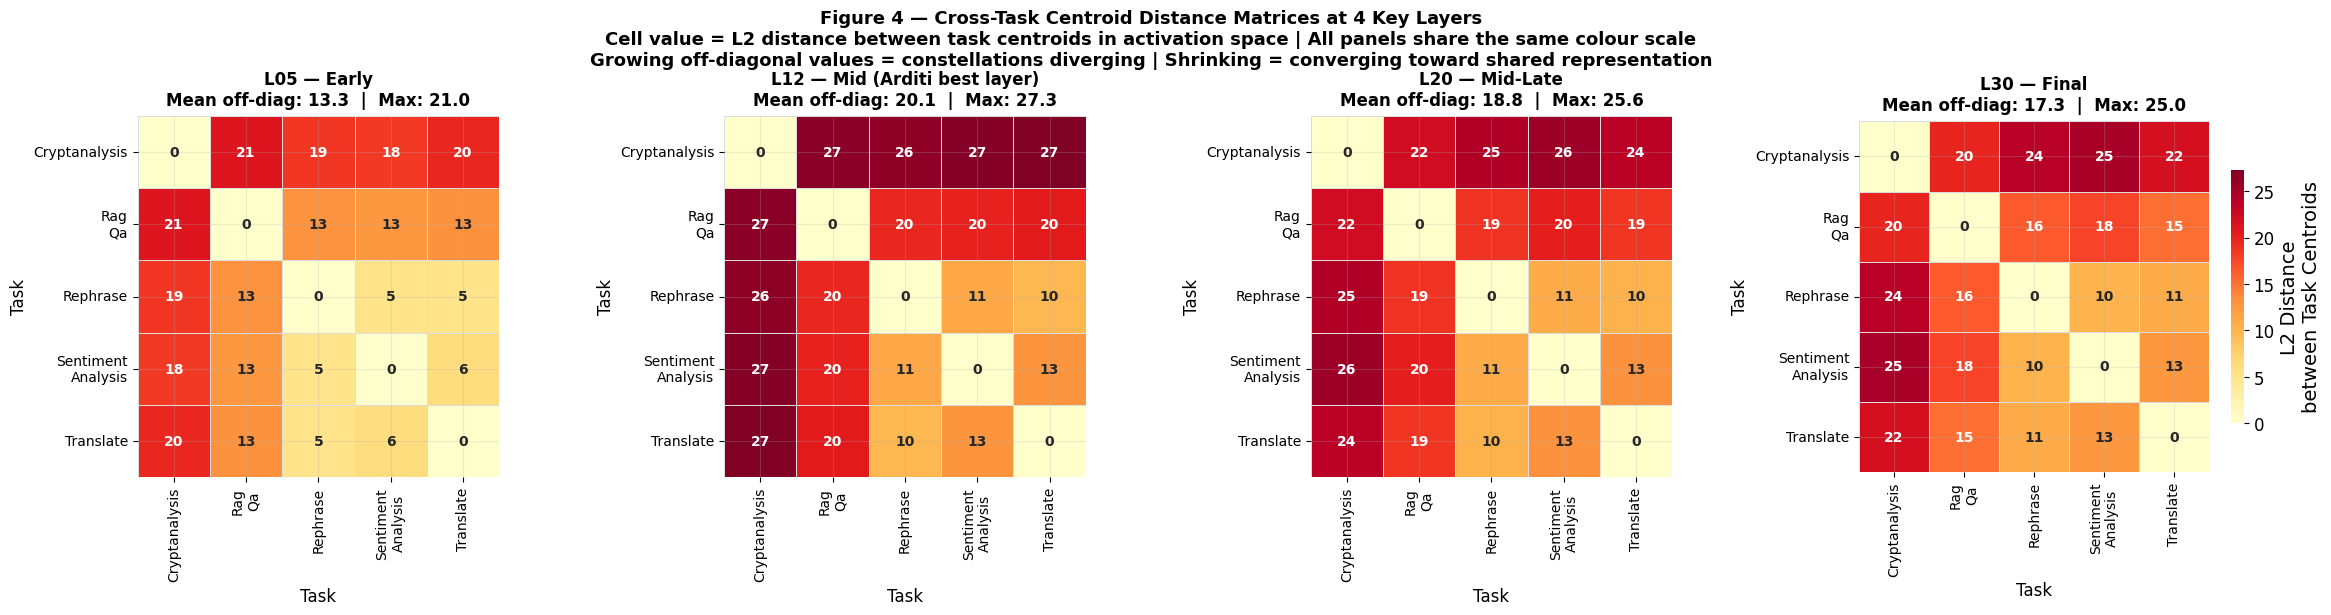

Saved: fig4_centroid_distance_heatmaps.pdf


In [15]:
# Figure 4 — Cross-Task Centroid Distance Heatmaps at 4 Key Layers
KEY_L = [
    ('layer_5_input_norm',  'L05 — Early'),
    ('layer_12_input_norm', 'L12 — Mid (Arditi best layer)'),
    ('layer_20_input_norm', 'L20 — Mid-Late'),
    ('layer_30_input_norm', 'L30 — Final'),
]
task_labels_short = [t.replace('_', '\n').title() for t in ALL_TASKS]

# Shared vmax across all 4 for fair comparison
vmax_global = max(
    centroid_matrices[k].max() for k, _ in KEY_L if k in centroid_matrices
)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (lname, title) in zip(axes, KEY_L):
    if lname not in centroid_matrices:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        continue
    mat = centroid_matrices[lname]
    off_diag_vals = mat[~np.eye(len(ALL_TASKS), dtype=bool)]
    mean_off = float(off_diag_vals.mean())
    max_off  = float(off_diag_vals.max())

    im = sns.heatmap(
        mat, ax=ax,
        xticklabels=task_labels_short,
        yticklabels=task_labels_short,
        cmap='YlOrRd', vmin=0, vmax=vmax_global,
        annot=True, fmt='.0f', annot_kws={'size': 10, 'weight': 'bold'},
        square=True, linewidths=0.4, linecolor='#ddd',
        cbar=(ax == axes[-1]),
        cbar_kws={'shrink': 0.7, 'label': 'L2 Distance\nbetween Task Centroids'},
    )
    ax.set_title(
        f'{title}\nMean off-diag: {mean_off:.1f}  |  Max: {max_off:.1f}',
        fontsize=12, fontweight='bold', pad=8,
    )
    ax.tick_params(labelsize=10, axis='both')
    ax.set_xlabel('Task', fontsize=12)
    ax.set_ylabel('Task', fontsize=12)

fig.suptitle(
    'Figure 4 — Cross-Task Centroid Distance Matrices at 4 Key Layers\n'
    'Cell value = L2 distance between task centroids in activation space | All panels share the same colour scale\n'
    'Growing off-diagonal values = constellations diverging | Shrinking = converging toward shared representation',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.savefig('fig4_centroid_distance_heatmaps.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig4_centroid_distance_heatmaps.pdf')

In [16]:
# Section 4 Findings — Centroid Distance Summary
print('=' * 68)
print('SECTION 4 FINDINGS — CROSS-TASK CENTROID DISTANCES')
print('=' * 68)
print(f'  {"Layer":<28} {"Mean off-diag":>15} {"Max off-diag":>14} {"Trend"}')
print(f'  {"-"*65}')

prev_mean = None
for lname, title in KEY_L:
    if lname not in centroid_matrices:
        print(f'  {title:<28} {"N/A":>15} {"N/A":>14}')
        continue
    mat      = centroid_matrices[lname]
    off_mask = ~np.eye(len(ALL_TASKS), dtype=bool)
    mean_off = float(mat[off_mask].mean())
    max_off  = float(mat[off_mask].max())
    trend    = ''
    if prev_mean is not None:
        diff  = mean_off - prev_mean
        trend = f'+{diff:.1f} (diverging)' if diff > 0 else f'{diff:.1f} (converging)'
    print(f'  {title:<28} {mean_off:>15.1f} {max_off:>14.1f}  {trend}')
    prev_mean = mean_off

print()
# Most / least separated task pair at L12
if 'layer_12_input_norm' in centroid_matrices:
    mat12 = centroid_matrices['layer_12_input_norm']
    off_idx = [(mat12[i,j], ALL_TASKS[i], ALL_TASKS[j])
               for i in range(len(ALL_TASKS)) for j in range(i+1, len(ALL_TASKS))]
    off_idx.sort(reverse=True)
    print(f'  At L12 (Arditi best layer):')
    print(f'    Most separated pair  : {off_idx[0][1]} vs {off_idx[0][2]} = {off_idx[0][0]:.1f}')
    print(f'    Least separated pair : {off_idx[-1][1]} vs {off_idx[-1][2]} = {off_idx[-1][0]:.1f}')
    ratio = off_idx[0][0] / (off_idx[-1][0] + 1e-6)
    print(f'    Spread ratio (max/min): {ratio:.1f}x — this is the within-layer task geometry Arditi ignores')
print('=' * 68)

SECTION 4 FINDINGS — CROSS-TASK CENTROID DISTANCES
  Layer                          Mean off-diag   Max off-diag Trend
  -----------------------------------------------------------------
  L05 — Early                             13.3           21.0  
  L12 — Mid (Arditi best layer)            20.1           27.3  +6.9 (diverging)
  L20 — Mid-Late                          18.8           25.6  -1.3 (converging)
  L30 — Final                             17.3           25.0  -1.5 (converging)

  At L12 (Arditi best layer):
    Most separated pair  : cryptanalysis vs translate = 27.3
    Least separated pair : rephrase vs translate = 9.7
    Spread ratio (max/min): 2.8x — this is the within-layer task geometry Arditi ignores


---
## Section 5 — Arditi Direction Validation: Is There a Universal Refusal Direction?

Arditi et al. claim a **single direction** mediates refusal across all inputs. In our data, we have 3 tasks with enough refused-harmful and harmless-answered samples to compute a task-specific refusal direction. We now ask:

**5a — Do task-specific refusal directions point the same way?** Compute cosine similarity between the task-specific directions at each layer. If all tasks share one direction: all cosine similarities → 1.0. If directions diverge: values fall below 1.0, revealing task-conditioned structure.

**5b — Does Arditi's direction capture each task's refusal direction?** Compute cosine similarity between each task's direction and Arditi's per-layer candidate direction. Near 1.0 = Arditi's direction fully represents that task. Divergence = a systematic gap.

**The key interpretive question:** Does direction convergence happen *before*, *during*, or *after* constellation formation? This determines whether Arditi's approach captures the mechanistically relevant layer.

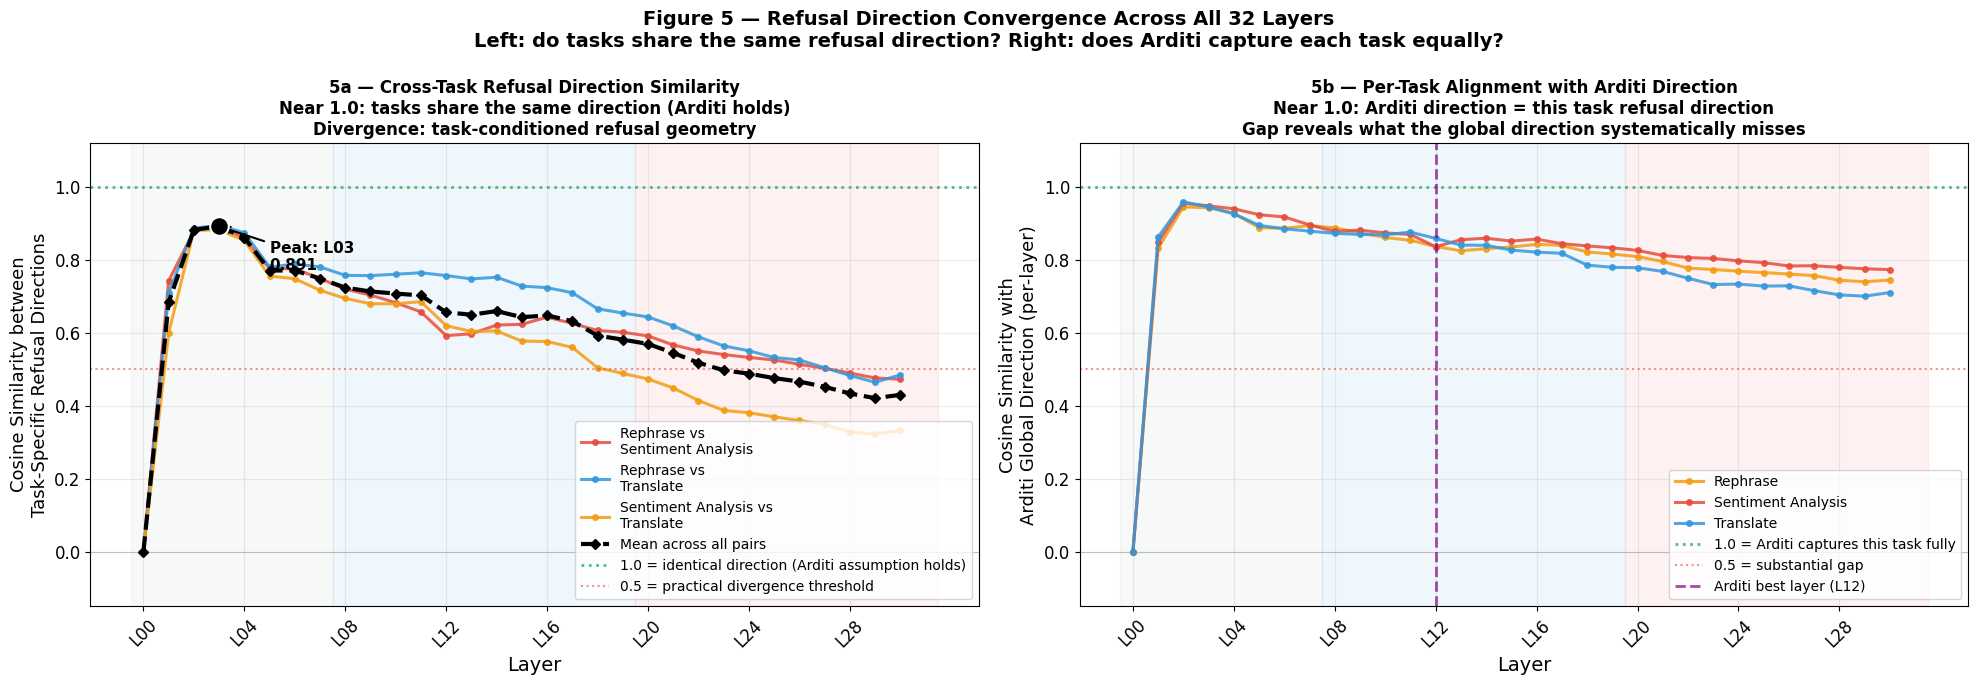

Saved: fig5_direction_convergence.pdf


In [17]:
# Figure 5 — Refusal Direction Convergence (2-panel)
PAIR_COLORS = ['#E74C3C', '#3498DB', '#F39C12', '#27AE60', '#9B59B6']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
xtick_pos    = list(range(0, N_LAYERS, 4))
xtick_labels = [f'L{i:02d}' for i in xtick_pos]

# ── Left panel: cross-task direction similarity ────────────────
ax = axes[0]
for (t1, t2), color in zip(dir_pairs, PAIR_COLORS):
    vals  = pair_sims[(t1, t2)]
    label = f'{t1.replace("_"," ").title()} vs\n{t2.replace("_"," ").title()}'
    ax.plot(range(N_LAYERS), vals, color=color, lw=2.2, marker='o', ms=4,
            label=label, alpha=0.85)

if mean_cross_sim:
    ax.plot(range(N_LAYERS), mean_cross_sim, color='black', lw=3.0, ls='--',
            marker='D', ms=5, label='Mean across all pairs', zorder=5)

ax.axhline(1.0, color='#27AE60', ls=':', lw=2.0, alpha=0.8,
           label='1.0 = identical direction (Arditi assumption holds)')
ax.axhline(0.5, color='#E74C3C', ls=':', lw=1.5, alpha=0.6,
           label='0.5 = practical divergence threshold')
ax.axhline(0.0, color='grey', ls='-', lw=0.8, alpha=0.4)

ax.axvspan(-0.5,  7.5, alpha=0.07, color='#95A5A6')
ax.axvspan( 7.5, 19.5, alpha=0.07, color='#3498DB')
ax.axvspan(19.5, 31.5, alpha=0.07, color='#E74C3C')

# Annotate peak convergence
if mean_cross_sim and not all(np.isnan(mean_cross_sim)):
    pk_i   = int(np.nanargmax(mean_cross_sim))
    pk_val = float(mean_cross_sim[pk_i])
    ax.scatter([pk_i], [pk_val], color='black', s=180, zorder=6,
               edgecolors='white', linewidths=1.5)
    ax.annotate(
        f'Peak: L{pk_i:02d}\n{pk_val:.3f}',
        xy=(pk_i, pk_val), xytext=(pk_i + 2, pk_val - 0.12),
        fontsize=11, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    )

ax.set_xlabel('Layer', fontsize=14)
ax.set_ylabel('Cosine Similarity between\nTask-Specific Refusal Directions', fontsize=13)
ax.set_title(
    '5a — Cross-Task Refusal Direction Similarity\n'
    'Near 1.0: tasks share the same direction (Arditi holds)\n'
    'Divergence: task-conditioned refusal geometry',
    fontsize=12, fontweight='bold',
)
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, rotation=45, fontsize=12)
ax.set_ylim(-0.15, 1.12)
ax.legend(fontsize=10, loc='lower right', frameon=True)

# ── Right panel: alignment with Arditi per task ────────────────
ax2 = axes[1]
for task, color in zip(VALID_DIR_TASKS, PAIR_COLORS):
    vals  = arditi_align.get(task, [np.nan] * N_LAYERS)
    ax2.plot(range(N_LAYERS), vals, color=TASK_COLORS.get(task, color),
             lw=2.2, marker='o', ms=4,
             label=task.replace('_', ' ').title(), alpha=0.85)

ax2.axhline(1.0, color='#27AE60', ls=':', lw=2.0, alpha=0.8,
            label='1.0 = Arditi captures this task fully')
ax2.axhline(0.5, color='#E74C3C', ls=':', lw=1.5, alpha=0.6,
            label='0.5 = substantial gap')
ax2.axhline(0.0, color='grey', ls='-', lw=0.8, alpha=0.4)

ax2.axvspan(-0.5,  7.5, alpha=0.07, color='#95A5A6')
ax2.axvspan( 7.5, 19.5, alpha=0.07, color='#3498DB')
ax2.axvspan(19.5, 31.5, alpha=0.07, color='#E74C3C')

# Annotate Arditi best layer
if 'layer_12_input_norm' in LAYER_NAMES:
    arditi_best_idx = LAYER_NAMES.index('layer_12_input_norm')
    ax2.axvline(arditi_best_idx, color='purple', ls='--', lw=2.0, alpha=0.7,
                label=f'Arditi best layer (L{arditi_best_idx:02d})')

ax2.set_xlabel('Layer', fontsize=14)
ax2.set_ylabel('Cosine Similarity with\nArditi Global Direction (per-layer)', fontsize=13)
ax2.set_title(
    '5b — Per-Task Alignment with Arditi Direction\n'
    'Near 1.0: Arditi direction = this task refusal direction\n'
    'Gap reveals what the global direction systematically misses',
    fontsize=12, fontweight='bold',
)
ax2.set_xticks(xtick_pos)
ax2.set_xticklabels(xtick_labels, rotation=45, fontsize=12)
ax2.set_ylim(-0.15, 1.12)
ax2.legend(fontsize=10, loc='lower right', frameon=True)

fig.suptitle(
    'Figure 5 — Refusal Direction Convergence Across All 32 Layers\n'
    'Left: do tasks share the same refusal direction? '
    'Right: does Arditi capture each task equally?',
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.savefig('fig5_direction_convergence.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig5_direction_convergence.pdf')

In [18]:
# Section 5 Findings — Direction Convergence Table
print('=' * 72)
print('SECTION 5 FINDINGS — REFUSAL DIRECTION CONVERGENCE ANALYSIS')
print('=' * 72)
print()
print('  5a: Mean cross-task refusal direction cosine similarity at key layers:')
print(f'  {"Layer":<8}', end='')
for t1, t2 in dir_pairs:
    label = f'{t1[:4]}vs{t2[:4]}'
    print(f'  {label:>10}', end='')
print(f'  {"Mean":>8}')
print(f'  {"-"*70}')
KEY_IDX = [0, 5, 8, 12, 15, 18, 20, 25, 30, 31]
for idx in KEY_IDX:
    if idx >= N_LAYERS:
        continue
    star = ' <-- Arditi best' if idx == 12 else ''
    print(f'  L{idx:02d}    ', end='')
    vals = []
    for p in dir_pairs:
        v = pair_sims[p][idx] if idx < len(pair_sims[p]) else np.nan
        vals.append(v)
        print(f'  {v:>10.3f}', end='')
    print(f'  {np.nanmean(vals):>8.3f}{star}')
print()
print('  5b: Per-task alignment with Arditi direction at key layers:')
print(f'  {"Layer":<8}', end='')
for t in VALID_DIR_TASKS:
    print(f'  {t[:16]:>16}', end='')
print()
print(f'  {"-"*60}')
for idx in KEY_IDX:
    if idx >= N_LAYERS:
        continue
    print(f'  L{idx:02d}    ', end='')
    for t in VALID_DIR_TASKS:
        v = arditi_align[t][idx] if idx < len(arditi_align.get(t, [])) else np.nan
        print(f'  {v:>16.3f}', end='')
    print()
print()
if mean_cross_sim and not all(np.isnan(mean_cross_sim)):
    pk_conv = int(np.nanargmax(mean_cross_sim))
    pk_val  = float(mean_cross_sim[pk_conv])
    pk_sep  = int(np.argmax(sep_vals))
    print(f'  Peak cross-task direction convergence : L{pk_conv:02d} = {pk_val:.3f}')
    print(f'  Peak constellation separation          : L{pk_sep:02d} = {sep_vals[pk_sep]:.3f}')
    if pk_conv < pk_sep:
        print(f'  ORDER: Direction converges (L{pk_conv:02d}) BEFORE constellations peak (L{pk_sep:02d})')
        print(f'  This means Arditi captures an early convergent signal;')
        print(f'  the task-specific constellation structure forms AFTER and is orthogonal to it.')
    elif pk_conv > pk_sep:
        print(f'  ORDER: Constellations peak (L{pk_sep:02d}) BEFORE direction converges (L{pk_conv:02d})')
        print(f'  Arditi captures a late-stage convergence point — the final common pathway.')
        print(f'  The constellation structure is task-specific in the mechanistically active window.')
    else:
        print(f'  Both peak at L{pk_conv:02d} simultaneously — convergence and constellation formation co-occur.')
print('=' * 72)

SECTION 5 FINDINGS — REFUSAL DIRECTION CONVERGENCE ANALYSIS

  5a: Mean cross-task refusal direction cosine similarity at key layers:
  Layer     rephvssent  rephvstran  sentvstran      Mean
  ----------------------------------------------------------------------
  L00           0.000       0.000       0.000     0.000
  L05           0.776       0.780       0.755     0.770
  L08           0.720       0.757       0.694     0.724
  L12           0.592       0.757       0.619     0.656 <-- Arditi best
  L15           0.623       0.728       0.577     0.643
  L18           0.606       0.666       0.504     0.592
  L20           0.591       0.643       0.473     0.569
  L25           0.525       0.532       0.370     0.476
  L30           0.473       0.484       0.332     0.430

  5b: Per-task alignment with Arditi direction at key layers:
  Layer             rephrase  sentiment_analys         translate
  ------------------------------------------------------------
  L00                 0.0

---
## Section 6 — Synthesis: The Complete Mechanistic Picture

This figure brings together all prior findings into a single two-panel view:

- **Left panel:** Constellation strength across layers (separation ratio + silhouette, both normalized to [0,1] for comparison). Shows when and how strongly task-specific representations form.
- **Right panel:** Cross-task refusal direction agreement across layers. Shows when Arditi's single-direction assumption is most valid.

**The critical question:** The relationship between these two curves determines the mechanistic story:
- If directions converge *before* or *during* constellation formation → Arditi captures the convergent signal, but constellations carry orthogonal structure he ignores.
- If directions converge *after* constellation formation → Arditi captures only the final common pathway, entirely missing the task-specific crystallization window.

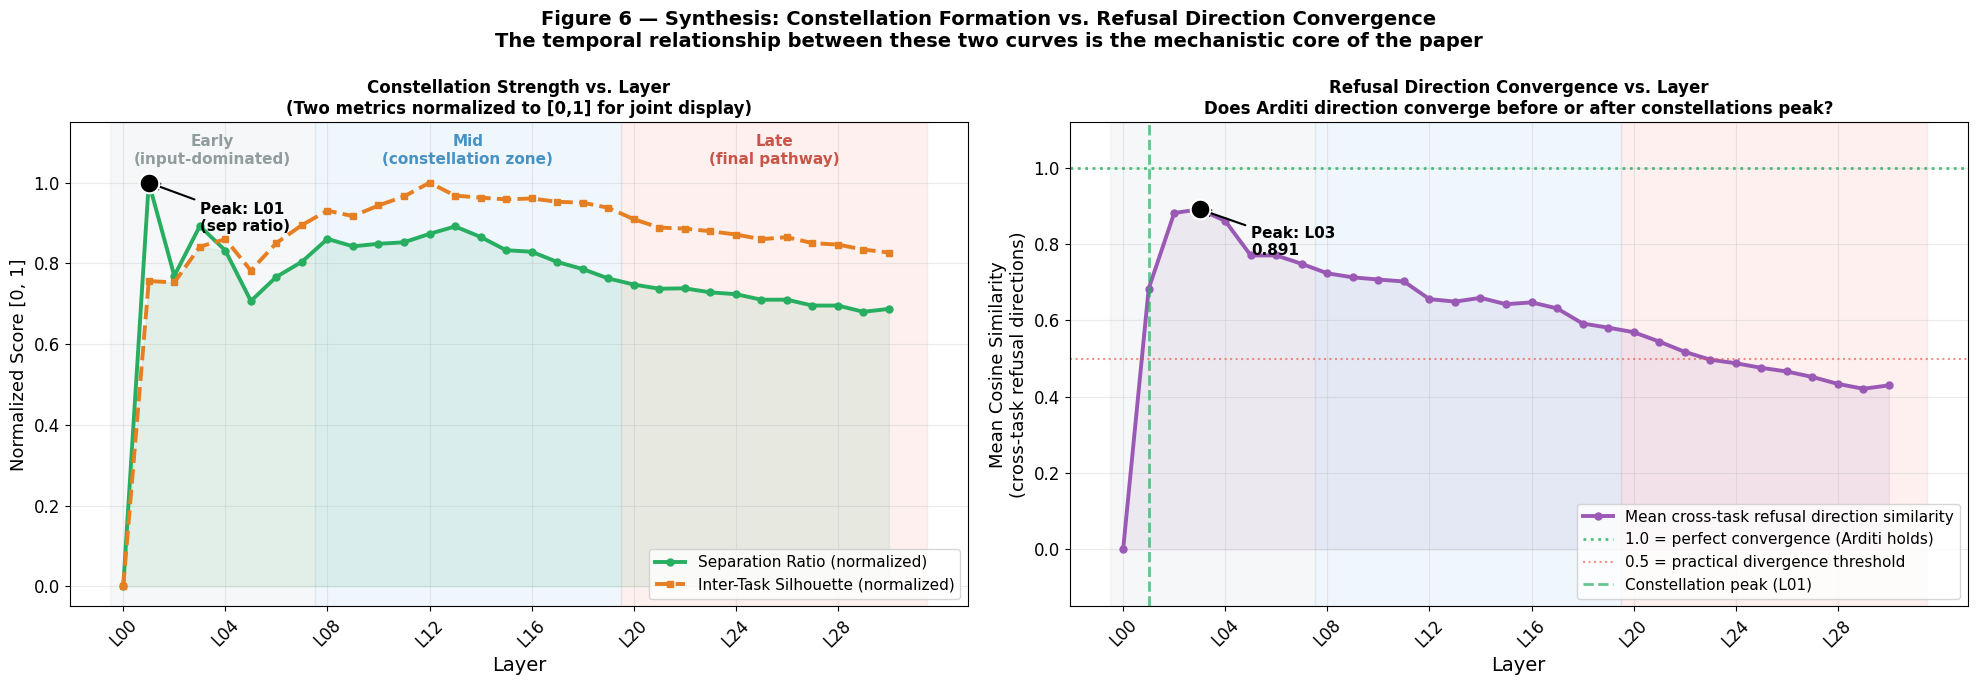

Saved: fig6_synthesis.pdf


In [19]:
# Figure 6 — Synthesis
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
xtick_pos    = list(range(0, N_LAYERS, 4))
xtick_labels = [f'L{i:02d}' for i in xtick_pos]

def norm01(arr):
    a = np.array(arr, dtype=float)
    lo, hi = np.nanmin(a), np.nanmax(a)
    return (a - lo) / (hi - lo + 1e-8)

sep_norm = norm01(sep_vals)
sil_norm = norm01(sil_vals)

# ── Left: constellation strength ──────────────────────────────
ax = axes[0]
ax.plot(range(N_LAYERS), sep_norm, color='#27AE60', lw=2.8, marker='o', ms=5,
        label='Separation Ratio (normalized)')
ax.plot(range(N_LAYERS), sil_norm, color='#E67E22', lw=2.8, marker='s', ms=5, ls='--',
        label='Inter-Task Silhouette (normalized)')
ax.fill_between(range(N_LAYERS), np.minimum(sep_norm, sil_norm), alpha=0.10, color='#27AE60')

ax.axvspan(-0.5,  7.5, alpha=0.08, color='#95A5A6')
ax.axvspan( 7.5, 19.5, alpha=0.08, color='#3498DB')
ax.axvspan(19.5, 31.5, alpha=0.08, color='#E74C3C')

# Annotate peak
pk_const = int(np.argmax(sep_norm))
ax.scatter([pk_const], [sep_norm[pk_const]], color='black', s=200, zorder=6,
           edgecolors='white', linewidths=1.5)
ax.annotate(f'Peak: L{pk_const:02d}\n(sep ratio)',
            xy=(pk_const, sep_norm[pk_const]),
            xytext=(pk_const + 2, sep_norm[pk_const] - 0.12),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

y_top = 1.04
for xc, lbl, c in [(3.5,'Early\n(input-dominated)','#7F8C8D'),
                   (13.5,'Mid\n(constellation zone)','#2980B9'),
                   (25.5,'Late\n(final pathway)','#C0392B')]:
    ax.text(xc, y_top, lbl, ha='center', va='bottom', fontsize=11,
            color=c, fontweight='bold', alpha=0.85)

ax.set_xlabel('Layer', fontsize=14)
ax.set_ylabel('Normalized Score [0, 1]', fontsize=13)
ax.set_title('Constellation Strength vs. Layer\n(Two metrics normalized to [0,1] for joint display)',
             fontsize=12, fontweight='bold')
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, rotation=45, fontsize=12)
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=11, loc='lower right')

# ── Right: refusal direction convergence ──────────────────────
ax2 = axes[1]
if mean_cross_sim and not all(np.isnan(mean_cross_sim)):
    ax2.plot(range(N_LAYERS), mean_cross_sim, color='#9B59B6', lw=2.8, marker='o', ms=5,
             label='Mean cross-task refusal direction similarity')
    ax2.fill_between(range(N_LAYERS), mean_cross_sim, alpha=0.10, color='#9B59B6')

    ax2.axhline(1.0, color='#27AE60', ls=':', lw=2.0, alpha=0.8,
                label='1.0 = perfect convergence (Arditi holds)')
    ax2.axhline(0.5, color='#E74C3C', ls=':', lw=1.5, alpha=0.6,
                label='0.5 = practical divergence threshold')

    pk_dir = int(np.nanargmax(mean_cross_sim))
    ax2.scatter([pk_dir], [mean_cross_sim[pk_dir]], color='black', s=200, zorder=6,
                edgecolors='white', linewidths=1.5)
    ax2.annotate(f'Peak: L{pk_dir:02d}\n{mean_cross_sim[pk_dir]:.3f}',
                 xy=(pk_dir, mean_cross_sim[pk_dir]),
                 xytext=(pk_dir + 2, mean_cross_sim[pk_dir] - 0.12),
                 fontsize=11, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

    # Overlay constellation peak as reference line
    ax2.axvline(pk_const, color='#27AE60', ls='--', lw=2.0, alpha=0.7,
                label=f'Constellation peak (L{pk_const:02d})')

ax2.axvspan(-0.5,  7.5, alpha=0.08, color='#95A5A6')
ax2.axvspan( 7.5, 19.5, alpha=0.08, color='#3498DB')
ax2.axvspan(19.5, 31.5, alpha=0.08, color='#E74C3C')

ax2.set_xlabel('Layer', fontsize=14)
ax2.set_ylabel('Mean Cosine Similarity\n(cross-task refusal directions)', fontsize=13)
ax2.set_title('Refusal Direction Convergence vs. Layer\n'
              'Does Arditi direction converge before or after constellations peak?',
              fontsize=12, fontweight='bold')
ax2.set_xticks(xtick_pos)
ax2.set_xticklabels(xtick_labels, rotation=45, fontsize=12)
ax2.set_ylim(-0.15, 1.12)
ax2.legend(fontsize=11, loc='lower right')

fig.suptitle(
    'Figure 6 — Synthesis: Constellation Formation vs. Refusal Direction Convergence\n'
    'The temporal relationship between these two curves is the mechanistic core of the paper',
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.savefig('fig6_synthesis.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig6_synthesis.pdf')

In [20]:
# Full NB13a Summary — Printed Report
print()
print('=' * 72)
print('NB13a COMPLETE FINDINGS REPORT')
print('=' * 72)

pk_sep = int(np.argmax(sep_vals))
pk_sil = int(np.nanargmax(sil_vals))

print()
print('[1] CONSTELLATION FORMATION')
print(f'    Peak separation ratio : L{pk_sep:02d} = {sep_vals[pk_sep]:.3f}')
print(f'    Peak silhouette score : L{pk_sil:02d} = {sil_vals[pk_sil]:.3f}')
print(f'    Phase silhouette means: early={np.nanmean(sil_vals[:8]):.3f} | '
      f'mid={np.nanmean(sil_vals[8:20]):.3f} | late={np.nanmean(sil_vals[20:]):.3f}')
print(f'    Finding: Constellation formation window is L08-L19 (mid-layers).')

print()
print('[2] REFUSAL CRYSTALLIZATION (within-task)')
for task in ALL_TASKS:
    row = [cryst_sil.get((task, l), np.nan) for l in LAYER_NAMES]
    if np.all(np.isnan(row)):
        print(f'    {task:<22}: insufficient data')
    else:
        pk  = int(np.nanargmax(row))
        val = float(np.nanmax(row))
        print(f'    {task:<22}: peaks at L{pk:02d} = {val:.3f}')

print()
print('[3] ARDITI DIRECTION VALIDITY')
if mean_cross_sim and not all(np.isnan(mean_cross_sim)):
    for idx in [0, 8, 12, 20, 31]:
        if idx < len(mean_cross_sim):
            print(f'    L{idx:02d} mean cross-task sim : {mean_cross_sim[idx]:.3f}')
    pk_dir = int(np.nanargmax(mean_cross_sim))
    print(f'    Peak convergence       : L{pk_dir:02d} = {mean_cross_sim[pk_dir]:.3f}')
    print(f'    Constellation peak     : L{pk_sep:02d} = {sep_vals[pk_sep]:.3f}')
    gap = pk_dir - pk_sep
    if gap > 0:
        print(f'    Verdict: Direction convergence is {gap} layers AFTER constellation peak.')
        print(f'    Arditi captures the late final-pathway signal, missing the mid-layer task structure.')
    elif gap < 0:
        print(f'    Verdict: Direction converges {abs(gap)} layers BEFORE constellation peak.')
        print(f'    Refusal direction convergence is early; constellations carry orthogonal structure.')
    else:
        print(f'    Verdict: Both peak at L{pk_sep:02d}. Convergence and constellation formation co-occur.')

print()
print('[4] SAVED FIGURES')
for fname in ['fig1_umap_galaxy_grid.pdf', 'fig2_layer_profile_metrics.pdf',
              'fig3_crystallization_heatmap.pdf', 'fig4_centroid_distance_heatmaps.pdf',
              'fig5_direction_convergence.pdf', 'fig6_synthesis.pdf']:
    exists = 'OK' if os.path.exists(fname) else 'MISSING'
    print(f'    {fname:<45} [{exists}]')

print()
print('Next: NB13b — apply Arditi to our task data, measure consequences, present task-aware fix.')
print('=' * 72)


NB13a COMPLETE FINDINGS REPORT

[1] CONSTELLATION FORMATION
    Peak separation ratio : L01 = 2.380
    Peak silhouette score : L12 = 0.357
    Phase silhouette means: early=0.256 | mid=0.341 | late=0.309
    Finding: Constellation formation window is L08-L19 (mid-layers).

[2] REFUSAL CRYSTALLIZATION (within-task)
    cryptanalysis         : insufficient data
    rag_qa                : insufficient data
    rephrase              : peaks at L19 = 0.066
    sentiment_analysis    : peaks at L16 = 0.076
    translate             : peaks at L17 = 0.081

[3] ARDITI DIRECTION VALIDITY
    L00 mean cross-task sim : 0.000
    L08 mean cross-task sim : 0.724
    L12 mean cross-task sim : 0.656
    L20 mean cross-task sim : 0.569
    Peak convergence       : L03 = 0.891
    Constellation peak     : L01 = 2.380
    Verdict: Direction convergence is 2 layers AFTER constellation peak.
    Arditi captures the late final-pathway signal, missing the mid-layer task structure.

[4] SAVED FIGURES
    f

In [21]:
# Save PDFs to Google Drive
os.makedirs('/content/drive/MyDrive/Colab Notebooks/SteeringFail/nb13a_figs', exist_ok=True)
for fname in ['fig1_umap_galaxy_grid.pdf', 'fig2_layer_profile_metrics.pdf',
              'fig3_crystallization_heatmap.pdf', 'fig4_centroid_distance_heatmaps.pdf',
              'fig5_direction_convergence.pdf', 'fig6_synthesis.pdf']:
    if os.path.exists(fname):
        !cp "{fname}" "/content/drive/MyDrive/Colab Notebooks/SteeringFail/nb13a_figs/"
        print(f'Saved to Drive: {fname}')
    else:
        print(f'Not found (run earlier cells first): {fname}')

Not found (run earlier cells first): fig1_umap_galaxy_grid.pdf
Saved to Drive: fig2_layer_profile_metrics.pdf
Saved to Drive: fig3_crystallization_heatmap.pdf
Saved to Drive: fig4_centroid_distance_heatmaps.pdf
Saved to Drive: fig5_direction_convergence.pdf
Saved to Drive: fig6_synthesis.pdf
